<a href="https://colab.research.google.com/github/SofiaChvokova/E-commerce-analitics/blob/main/ecommerce_user_behavior_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ поведения пользователей интернет-магазина

## О проекте

В проекте исследуется поведение пользователей интернет-магазина электроники.

Данные представлены в событийном формате: каждая строка соответствует отдельному действию пользователя с определённым товаром в конкретный момент времени.

Основные действия пользователей:

- просмотр товара;
- добавление товара в корзину;
- покупка.

Данные позволяют анализировать не только продажи, но и полный путь пользователя внутри продукта: от первого просмотра товара до покупки, повторных посещений и последующих покупок.

## Цель исследования

Изучить поведение пользователей интернет-магазина и определить закономерности, связанные с конверсией, повторными покупками, удержанием пользователей и их ценностью для бизнеса.

В рамках исследования необходимо:

- провести проверку и предобработку данных;
- изучить основные характеристики пользователей и их поведения;
- рассчитать ключевые продуктовые и коммерческие метрики;
- построить пользовательскую воронку;
- определить основные точки потери пользователей;
- сравнить поведение первых и повторных посещений;
- исследовать повторные покупки;
- провести когортный анализ;
- рассчитать retention;
- оценить накопленную ценность пользователей;
- сформулировать и проверить аналитические гипотезы;
- определить наиболее важные закономерности;
- сформулировать выводы и возможные бизнес-рекомендации.

## Основные вопросы исследования

1. Как пользователи проходят путь от просмотра товара до покупки?
2. На каком этапе воронки происходит наибольшая потеря пользователей?
3. Чем поведение покупателей отличается от поведения пользователей без покупки?
4. Отличаются ли первые и повторные посещения?
5. Как часто покупатели совершают повторные покупки?
6. Через какое время пользователи возвращаются после первой покупки?
7. Как меняется retention разных когорт?
8. Какие когорты и пользовательские сегменты создают наибольшую ценность?
9. Какие особенности пользовательского поведения связаны с более высокой вероятностью покупки?

## Ограничение LTV

Датасет содержит ограниченный период наблюдений, поэтому полный жизненный цикл клиента неизвестен.

По этой причине в проекте рассчитывается наблюдаемая накопленная ценность пользователя за доступный период — **Observed LTV**, а не прогноз полного Lifetime Value.

Данные являются наблюдательными, поэтому обнаруженные зависимости нельзя автоматически интерпретировать как причинно-следственные.

## Загрузка данных

Датасет: **eCommerce events history in electronics store** с Kaggle.

Файл `events.csv` хранится в Google Drive.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path = "/content/drive/MyDrive/ecommerce_analysis/data/events.csv"

df = pd.read_csv(path)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


## Первичный аудит данных

Сначала данные рассматриваются в исходном виде без очистки и преобразований.

In [5]:
print("Строк:", df.shape[0])
print("Столбцов:", df.shape[1])

Строк: 885129
Столбцов: 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [7]:
df.columns.tolist()

['event_time',
 'event_type',
 'product_id',
 'category_id',
 'category_code',
 'brand',
 'price',
 'user_id',
 'user_session']

In [8]:
df.sample(10, random_state=42)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
192708,2020-11-01 14:36:11 UTC,view,4156279,2144415922587172973,electronics.telephone,NaN,12.22,1515915625533221908,krDzDYA6J0
43645,2020-10-04 13:48:49 UTC,view,1283611,2144415952391898012,appliances.environment.vacuum,bort,170.00,1515915625469806973,C8YU0DjTP8
148601,2020-10-25 06:27:19 UTC,view,3791351,2144415926966026460,computers.components.cpu,amd,204.29,1515915625530210252,GFm0pEaVjK
592601,2021-01-12 08:26:56 UTC,view,3957221,2144415922427789416,computers.components.videocards,asus,451.32,1515915625592186998,E57Elq8HVE
355859,2020-11-26 12:29:34 UTC,view,227145,2144415921085612102,NaN,NaN,13.00,1515915625544205939,jvqzdCSUUw
92251,2020-10-15 11:12:31 UTC,view,606348,2144415925011480748,stationery.cartrige,netproduct,13.57,1515915625526325182,ZFVufBPJdu
301609,2020-11-17 17:49:12 UTC,purchase,564740,2144415935673401802,NaN,NaN,11.56,1515915625540490356,MpVLUpcIUV
307606,2020-11-18 13:24:19 UTC,view,1745516,2144415924021624977,electronics.tablet,baseus,35.87,1515915625540835817,yw3b6lL9Yj
396823,2020-12-04 20:12:08 UTC,view,1703779,2144415936369656286,computers.notebook,i-blason,24.76,1515915625548732634,dOFkFiD6dZ
281742,2020-11-15 01:22:29 UTC,view,1301733,2144415925196030129,electronics.telephone,ark,61.16,1515915625539480805,1ZCUWd24WC


In [9]:
df["event_type"].value_counts()

,count
event_type,
view,793748
cart,54035
purchase,37346


In [10]:
df["event_type"].value_counts(normalize=True).mul(100).round(2)

,proportion
event_type,
view,89.68
cart,6.10
purchase,4.22


In [11]:
print("Пользователей:", df["user_id"].nunique())
print("Сессий по исходному user_session:", df["user_session"].nunique())
print("Товаров:", df["product_id"].nunique())
print("Категорий:", df["category_id"].nunique())
print("Брендов:", df["brand"].nunique())

Пользователей: 407283
Сессий по исходному user_session: 490398
Товаров: 53453
Категорий: 718
Брендов: 999


In [12]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": df.isna().mean().mul(100).round(2)
})

missing

,missing,percent
event_time,0,0.00
event_type,0,0.00
product_id,0,0.00
category_id,0,0.00
category_code,236219,26.69
brand,212364,23.99
price,0,0.00
user_id,0,0.00
user_session,165,0.02


In [13]:
df.duplicated().sum()

np.int64(655)

In [14]:
df["price"].describe()

,price
count,885129.000000
mean,146.328713
std,296.807683
min,0.220000
25%,26.460000
50%,65.710000
75%,190.490000
max,64771.060000


In [15]:
print("Нулевая цена:", (df["price"] == 0).sum())
print("Отрицательная цена:", (df["price"] < 0).sum())

Нулевая цена: 0
Отрицательная цена: 0


In [16]:
df.nlargest(20, "price")[[
    "product_id", "category_code", "brand", "price", "event_type"
]]

,product_id,category_code,brand,price,event_type
51272,4170916,computers.peripherals.monitor,lg,64771.06,view
86316,4170916,computers.peripherals.monitor,lg,64771.06,view
418716,4170916,computers.peripherals.monitor,lg,64771.06,view
627562,4170916,computers.peripherals.monitor,lg,64771.06,view
298701,4078837,electronics.video.tv,samsung,42590.13,view
324573,4078837,electronics.video.tv,samsung,42590.13,view
395298,4078837,electronics.video.tv,samsung,42590.13,view
866584,4078837,electronics.video.tv,samsung,42590.13,view
13638,4078834,electronics.video.tv,samsung,27775.87,view
20028,4078834,electronics.video.tv,samsung,27775.87,view


In [17]:
df["price"].quantile([0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 1])

,price
0.500,65.71
0.900,397.48
0.950,486.81
0.990,889.98
0.995,1199.11
0.999,2570.73
1.000,64771.06


In [18]:
df["brand"].value_counts().head(15)

,count
brand,
asus,27706
gigabyte,27673
msi,24877
palit,24802
samsung,23208
amd,20110
canon,18438
panasonic,11992
pioneer,11467


In [19]:
df["category_code"].value_counts().head(15)

,count
category_code,
computers.components.videocards,116717
electronics.telephone,84360
computers.peripherals.printer,43224
stationery.cartrige,38725
electronics.audio.acoustic,26766
computers.components.motherboard,26604
computers.notebook,25032
computers.components.cpu,24773
electronics.video.tv,21398


In [20]:
event_time = pd.to_datetime(df["event_time"], utc=True)

print("Начало периода:", event_time.min())
print("Конец периода:", event_time.max())

Начало периода: 2020-09-24 11:57:06+00:00
Конец периода: 2021-02-28 23:59:09+00:00


In [21]:
summary = pd.DataFrame({
    "metric": [
        "events",
        "users",
        "sessions",
        "products",
        "categories",
        "brands",
        "duplicates"
    ],
    "value": [
        len(df),
        df["user_id"].nunique(),
        df["user_session"].nunique(),
        df["product_id"].nunique(),
        df["category_id"].nunique(),
        df["brand"].nunique(),
        df.duplicated().sum()
    ]
})

summary

,metric,value
0,events,885129
1,users,407283
2,sessions,490398
3,products,53453
4,categories,718
5,brands,999
6,duplicates,655


### Результаты первичного аудита

В исходном датасете:

- 885 129 событий;
- 407 283 пользователя;
- 490 398 уникальных значений `user_session`;
- 53 453 товара;
- 718 категорий;
- 999 брендов;
- период наблюдений: с 24 сентября 2020 года по 28 февраля 2021 года.

По типам событий:

- `view` — 89,68%;
- `cart` — 6,10%;
- `purchase` — 4,22%.

Доля `purchase` среди событий не является пользовательской конверсией: одна строка соответствует событию, а один пользователь может совершить множество действий.

Пропуски наиболее заметны в `category_code` — 26,69% и `brand` — 23,99%. В `user_session` отсутствуют только 165 значений.

Обнаружено 655 полных дубликатов.

Распределение цены имеет длинный правый хвост: медиана составляет 65,71, 99-й перцентиль — 889,98, а максимальное значение — 64 771,06. Экстремальные значения относятся к конкретным дорогим товарам и не удаляются автоматически.

## Предобработка данных

Перед проведением анализа необходимо подготовить данные.

Пропуски в `category_code` и `brand` не являются основанием для удаления события, поскольку идентификаторы товара и пользователя сохранены. Такие значения объединяются в отдельную категорию `unknown`.

Строки без `user_session` исключаются: их доля крайне мала, а отсутствие идентификатора затрудняет анализ поведения.

Полные дубликаты удаляются.

Экстремальные значения цены сохраняются, поскольку нет оснований считать их ошибочными.

In [22]:
df[df["user_session"].isna()]["event_type"].value_counts()

,count
event_type,
view,159
cart,6


In [23]:
df[df.duplicated(keep=False)].sort_values(
    ["user_id", "event_time"]
).head(20)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
135997,2020-10-22 18:32:04 UTC,view,478724,2144415924491387038,computers.components.motherboard,asus,52.90,1515915625367766093,r5QKrUaDgr
135998,2020-10-22 18:32:04 UTC,view,478724,2144415924491387038,computers.components.motherboard,asus,52.90,1515915625367766093,r5QKrUaDgr
132075,2020-10-22 07:46:41 UTC,view,622757,2144415926848585945,NaN,NaN,102.16,1515915625373342675,obu3k5f27J
132076,2020-10-22 07:46:41 UTC,view,622757,2144415926848585945,NaN,NaN,102.16,1515915625373342675,obu3k5f27J
53101,2020-10-06 12:58:49 UTC,view,4099841,2144415922125799520,NaN,palmexx,56.67,1515915625388149041,ZlIip8HCO3
53102,2020-10-06 12:58:49 UTC,view,4099841,2144415922125799520,NaN,palmexx,56.67,1515915625388149041,ZlIip8HCO3
36875,2020-10-02 20:32:16 UTC,view,4079447,2144415926848585945,NaN,nzxt,158.17,1515915625424957684,7TcCWAT6S9
36876,2020-10-02 20:32:16 UTC,view,4079447,2144415926848585945,NaN,nzxt,158.17,1515915625424957684,7TcCWAT6S9
45272,2020-10-04 21:04:09 UTC,view,4078407,2144415926966026460,computers.components.cpu,amd,365.38,1515915625453727914,28821430-fbaf-4c08-8e7a-ac7fa3307b47
45273,2020-10-04 21:04:09 UTC,view,4078407,2144415926966026460,computers.components.cpu,amd,365.38,1515915625453727914,28821430-fbaf-4c08-8e7a-ac7fa3307b47


In [24]:
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)

df["category_code"] = df["category_code"].fillna("unknown")
df["brand"] = df["brand"].fillna("unknown")

df = df.dropna(subset=["user_session"])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

df["date"] = df["event_time"].dt.date
df["month"] = df["event_time"].dt.strftime("%Y-%m")
df["weekday"] = df["event_time"].dt.day_name()
df["hour"] = df["event_time"].dt.hour

In [25]:
quality = pd.DataFrame({
    "metric": [
        "rows",
        "users",
        "products",
        "duplicates",
        "missing_values"
    ],
    "value": [
        len(df),
        df["user_id"].nunique(),
        df["product_id"].nunique(),
        df.duplicated().sum(),
        df.isna().sum().sum()
    ]
})

quality

,metric,value
0,rows,884312
1,users,407237
2,products,53452
3,duplicates,0
4,missing_values,0


In [26]:
removed = 885129 - len(df)

print("Удалено строк:", removed)
print("Доля удалённых:", round(removed / 885129 * 100, 3), "%")

Удалено строк: 817
Доля удалённых: 0.092 %


### Результат предобработки

После очистки в датасете осталось **884 312 событий**.

Было удалено менее 0,1% исходных наблюдений: строки без идентификатора сессии и полные дубликаты.

Пропущенные значения `category_code` и `brand` были сохранены в отдельной категории `unknown`.

Экстремальные значения стоимости товаров не были автоматически признаны ошибочными и сохранены для дальнейшего анализа.

## Определение пользовательской сессии

Дополнительная проверка показала, что исходный `user_session` нельзя использовать как надёжную границу пользовательского визита.

Один идентификатор может встречаться у нескольких пользователей, а у одного пользователя сохраняться на протяжении недель или месяцев. Это приводит к нереалистичной длительности сессий.

Для дальнейшего анализа используется аналитическое определение сессии: новая сессия начинается, если между двумя последовательными действиями одного пользователя прошло более **30 минут**.

In [27]:
df.groupby("user_session")["user_id"].nunique().max()

12

In [28]:
raw_session_stats = df.groupby(["user_id", "user_session"]).agg(
    start_time=("event_time", "min"),
    end_time=("event_time", "max")
).reset_index()

raw_session_stats["duration_min"] = (
    raw_session_stats["end_time"] - raw_session_stats["start_time"]
).dt.total_seconds() / 60

raw_session_stats["duration_min"].quantile(
    [0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1]
)

,duration_min
0.500,0.000000
0.750,0.500000
0.900,9.150000
0.950,56.200000
0.990,8503.941333
0.999,76704.670400
1.000,223240.283333


In [29]:
df = df.sort_values(["user_id", "event_time"]).reset_index(drop=True)

df["time_gap"] = (
    df.groupby("user_id")["event_time"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

df["time_gap"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

,time_gap
count,477075.000000
mean,1564.919268
std,9225.151294
min,0.000000
50%,1.566667
75%,11.416667
90%,1184.393333
95%,5028.123333
99%,41825.990667
max,215797.600000


In [30]:
df["new_session"] = (
    df["time_gap"].isna()
    | (df["time_gap"] > 30)
).astype(int)

df["session_number"] = (
    df.groupby("user_id")["new_session"]
    .cumsum()
)

df["analysis_session_id"] = (
    df["user_id"].astype(str)
    + "_"
    + df["session_number"].astype(str)
)

print("Аналитических сессий:", df["analysis_session_id"].nunique())

Аналитических сессий: 504630


In [31]:
session_stats = df.groupby("analysis_session_id").agg(
    user_id=("user_id", "first"),
    start_time=("event_time", "min"),
    end_time=("event_time", "max"),
    events=("event_type", "size"),
    products=("product_id", "nunique"),
    categories=("category_id", "nunique")
).reset_index()

session_events = (
    df.groupby(["analysis_session_id", "event_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

session_stats = session_stats.merge(
    session_events,
    on="analysis_session_id",
    how="left"
)

session_stats["duration_min"] = (
    session_stats["end_time"] - session_stats["start_time"]
).dt.total_seconds() / 60

session_stats["has_purchase"] = session_stats["purchase"] > 0

In [32]:
session_stats[
    ["events", "products", "categories", "duration_min"]
].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

,events,products,categories,duration_min
count,504630.000000,504630.000000,504630.000000,504630.000000
mean,1.752397,1.281630,1.036514,2.036615
std,2.075689,1.128668,0.303757,6.810724
min,1.000000,1.000000,1.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,1.000000,0.433333
90%,3.000000,2.000000,1.000000,5.216667
95%,5.000000,3.000000,1.000000,12.700000
99%,10.000000,6.000000,2.000000,32.433333
max,260.000000,121.000000,68.000000,247.316667


In [33]:
single_event_share = session_stats["events"].eq(1).mean() * 100
session_conversion = session_stats["has_purchase"].mean() * 100

print("Сессии с одним событием:", round(single_event_share, 2), "%")
print("Сессии с покупкой:", round(session_conversion, 2), "%")

Сессии с одним событием: 70.1 %
Сессии с покупкой: 4.86 %


In [34]:
user_stats = df.groupby("user_id").agg(
    events=("event_type", "size"),
    sessions=("analysis_session_id", "nunique"),
    first_event=("event_time", "min"),
    last_event=("event_time", "max")
).reset_index()

user_purchases = (
    df[df["event_type"] == "purchase"]
    .groupby("user_id")
    .size()
    .reset_index(name="purchase_events")
)

user_stats = user_stats.merge(
    user_purchases,
    on="user_id",
    how="left"
)

user_stats["purchase_events"] = (
    user_stats["purchase_events"]
    .fillna(0)
    .astype(int)
)

In [35]:
user_stats[
    ["events", "sessions", "purchase_events"]
].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

,events,sessions,purchase_events
count,407237.000000,407237.000000,407237.000000
mean,2.171492,1.239156,0.091698
std,4.405577,1.559310,0.557732
min,1.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,2.000000,1.000000,0.000000
90%,4.000000,2.000000,0.000000
95%,6.000000,2.000000,1.000000
99%,16.000000,5.000000,2.000000
max,572.000000,266.000000,56.000000


In [36]:
one_session = user_stats["sessions"].eq(1).mean() * 100
multiple_sessions = user_stats["sessions"].gt(1).mean() * 100
buyers_share = user_stats["purchase_events"].gt(0).mean() * 100

print("Одна сессия:", round(one_session, 2), "%")
print("Больше одной сессии:", round(multiple_sessions, 2), "%")
print("Пользователи с покупкой:", round(buyers_share, 2), "%")

Одна сессия: 88.75 %
Больше одной сессии: 11.25 %
Пользователи с покупкой: 5.23 %


### Результаты анализа сессий

После разбиения активности по 30-минутному правилу получено **504 630 аналитических сессий**.

- 70,1% сессий содержат только одно событие;
- 88,75% пользователей имеют только одну аналитическую сессию;
- 11,25% пользователей имеют более одной сессии;
- 4,86% сессий содержат покупку.

Эти показатели не интерпретируются как retention, поскольку пользователи впервые появляются в разные моменты времени и имеют разный доступный период для повторного посещения.

## EDA: динамика активности и монетизации

In [37]:
purchases = df[df["event_type"] == "purchase"].copy()

purchase_prices = purchases["price"]

purchase_prices.describe(
    percentiles=[0.9, 0.95, 0.99, 0.995, 0.999]
)

,price
count,37343.000000
mean,137.244301
std,169.938356
min,0.220000
50%,64.480000
90%,397.480000
95%,479.510000
99%,656.630000
99.5%,839.750000
99.9%,1275.020000


In [38]:
purchases.nlargest(10, "price")[[
    "product_id", "category_code", "brand", "price"
]]

,product_id,category_code,brand,price
233942,4101658,computers.notebook,apple,3717.65
518533,4101658,computers.notebook,apple,3717.65
25261,4101673,computers.notebook,apple,3267.06
196474,3793171,electronics.video.tv,samsung,3094.60
669404,4155076,computers.notebook,apple,3033.54
438816,914134,computers.peripherals.printer,ricoh,2886.71
556604,1549677,electronics.video.projector,lg,2568.08
59372,3660773,electronics.video.projector,benq,2170.57
27200,3891956,electronics.video.tv,lg,2142.75
498500,4005185,computers.notebook,apple,1828.40


In [39]:
session_stats["month"] = session_stats["start_time"].dt.strftime("%Y-%m")

monthly_sessions = (
    session_stats.groupby("month")
    .size()
    .reset_index(name="sessions")
)

monthly = df.groupby("month").agg(
    events=("event_type", "size"),
    users=("user_id", "nunique")
).reset_index()

monthly_purchases = (
    purchases.groupby("month")
    .agg(
        purchase_events=("event_type", "size"),
        buyers=("user_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

monthly = monthly.merge(
    monthly_sessions,
    on="month",
    how="left"
)

monthly = monthly.merge(
    monthly_purchases,
    on="month",
    how="left"
)

monthly["user_conversion"] = monthly["buyers"] / monthly["users"] * 100
monthly["revenue_per_user"] = monthly["revenue"] / monthly["users"]
monthly["revenue_per_buyer"] = monthly["revenue"] / monthly["buyers"]
monthly["avg_purchase_price"] = monthly["revenue"] / monthly["purchase_events"]

monthly.round(2)

,month,events,users,sessions,purchase_events,buyers,revenue,user_conversion,revenue_per_user,revenue_per_buyer,avg_purchase_price
0,2020-09,28054,15333,17461,1007,627,96353.01,4.09,6.28,153.67,95.68
1,2020-10,161389,84204,98486,6276,3796,562590.39,4.51,6.68,148.21,89.64
2,2020-11,188037,92583,110501,7574,4328,787886.24,4.67,8.51,182.04,104.03
3,2020-12,152540,72131,86918,6529,3869,813068.01,5.36,11.27,210.15,124.53
4,2021-01,187424,81248,100580,8315,4771,1488410.57,5.87,18.32,311.97,179.00
5,2021-02,166868,74604,90684,7642,4341,1376805.70,5.82,18.45,317.16,180.16


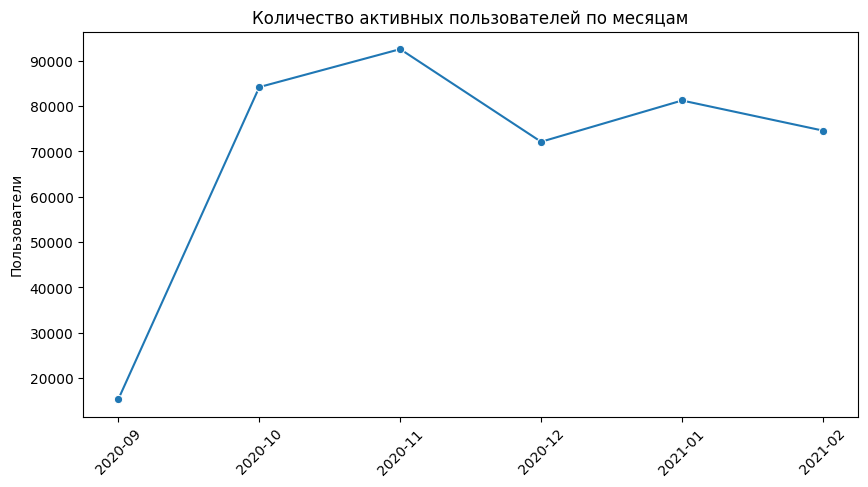

In [40]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x="month", y="users", marker="o")
plt.title("Количество активных пользователей по месяцам")
plt.xlabel("")
plt.ylabel("Пользователи")
plt.xticks(rotation=45)
plt.show()

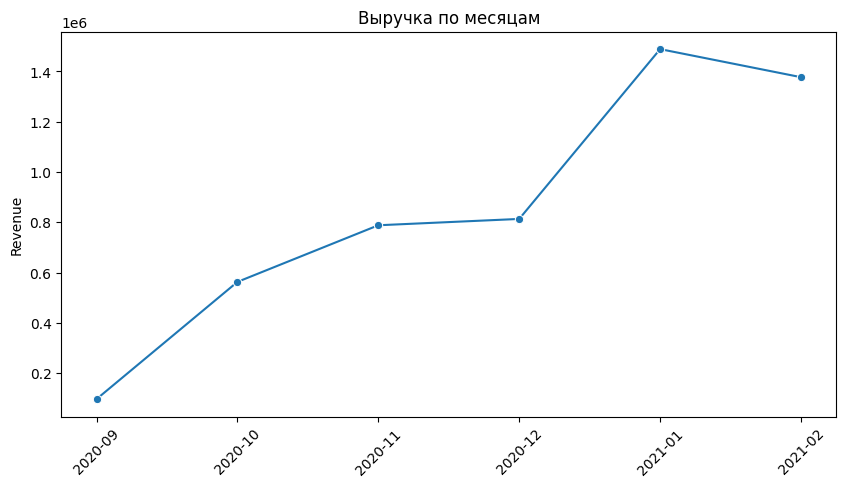

In [41]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x="month", y="revenue", marker="o")
plt.title("Выручка по месяцам")
plt.xlabel("")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

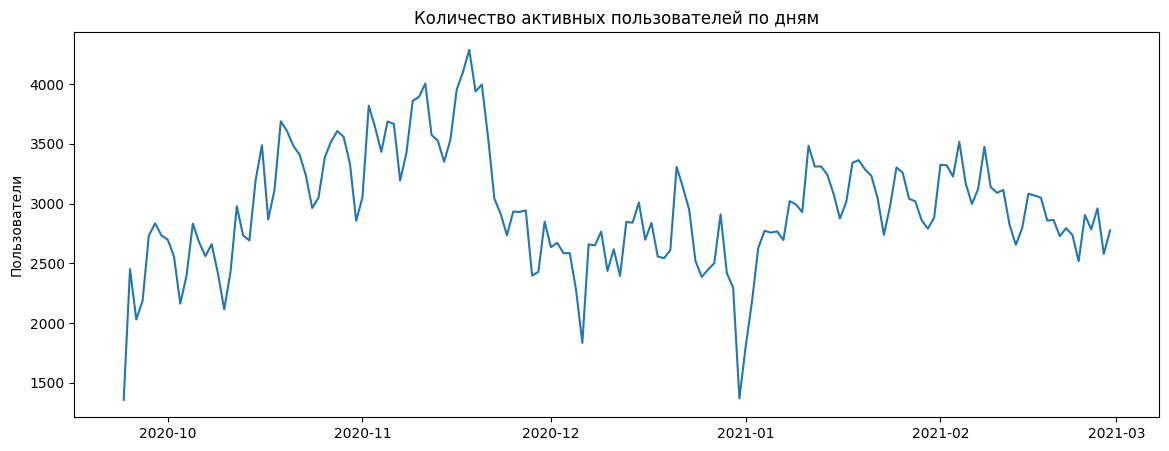

In [42]:
daily = df.groupby("date").agg(
    events=("event_type", "size"),
    users=("user_id", "nunique"),
    sessions=("analysis_session_id", "nunique")
).reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x="date", y="users")
plt.title("Количество активных пользователей по дням")
plt.xlabel("")
plt.ylabel("Пользователи")
plt.show()

### Динамика монетизации

С ноября 2020 года по январь 2021 года количество активных пользователей снизилось примерно на 12%, однако количество покупателей выросло примерно на 10%.

User Conversion увеличилась с 4,67% до 5,87%, а средняя стоимость purchase-события — примерно со 104 до 179.

В результате месячная выручка выросла почти на 89% — с 787,9 тыс. до 1,49 млн.

Рост выручки происходил не за счёт увеличения аудитории. Далее исследуется изменение воронки и структуры продаж.

## Продуктовая воронка

Воронка рассматривается на нескольких уровнях. Основной итоговый вариант рассчитывается для пары `сессия × товар`, чтобы просмотр, добавление в корзину и покупка относились к одному и тому же товару.

In [43]:
user_events = (
    df.groupby(["user_id", "event_type"])
    .size()
    .unstack(fill_value=0)
)

user_events = user_events[["view", "cart", "purchase"]]
user_flags = user_events.gt(0)

user_funnel = pd.DataFrame({
    "stage": ["View", "Cart", "Purchase"],
    "users": [
        user_flags["view"].sum(),
        user_flags["cart"].sum(),
        user_flags["purchase"].sum()
    ]
})

user_funnel["share"] = (
    user_funnel["users"] / user_funnel["users"].iloc[0] * 100
)

user_funnel

,stage,users,share
0,View,406817,100.000000
1,Cart,36948,9.082216
2,Purchase,21304,5.236753


In [44]:
session_events = (
    df.groupby(["analysis_session_id", "event_type"])
    .size()
    .unstack(fill_value=0)
)

session_events = session_events[["view", "cart", "purchase"]]
session_flags = session_events.gt(0)

session_patterns = session_flags.value_counts().reset_index(name="sessions")
session_patterns["share"] = (
    session_patterns["sessions"]
    / session_patterns["sessions"].sum()
    * 100
)

session_patterns

,view,cart,purchase,sessions,share
0,True,False,False,459324,91.021937
1,True,True,True,21793,4.318610
2,True,True,False,20577,4.077641
3,True,False,True,1425,0.282385
4,False,False,True,1028,0.203714
5,False,True,True,260,0.051523
6,False,True,False,223,0.044191


In [45]:
purchase_sessions_check = session_flags[session_flags["purchase"]]

without_cart = (~purchase_sessions_check["cart"]).mean() * 100
without_view = (~purchase_sessions_check["view"]).mean() * 100

print("Покупок без cart в сессии:", round(without_cart, 2), "%")
print("Покупок без view в сессии:", round(without_view, 2), "%")

Покупок без cart в сессии: 10.01 %
Покупок без view в сессии: 5.26 %


In [46]:
product_session_events = (
    df.groupby(
        ["analysis_session_id", "product_id", "event_type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

product_session_events["has_view"] = product_session_events["view"] > 0
product_session_events["has_cart"] = product_session_events["cart"] > 0
product_session_events["has_purchase"] = product_session_events["purchase"] > 0

In [47]:
product_view_to_cart = (
    (
        product_session_events["has_view"]
        & product_session_events["has_cart"]
    ).sum()
    / product_session_events["has_view"].sum()
    * 100
)

product_cart_to_purchase = (
    (
        product_session_events["has_cart"]
        & product_session_events["has_purchase"]
    ).sum()
    / product_session_events["has_cart"].sum()
    * 100
)

product_view_to_purchase = (
    (
        product_session_events["has_view"]
        & product_session_events["has_purchase"]
    ).sum()
    / product_session_events["has_view"].sum()
    * 100
)

print("View → Cart:", round(product_view_to_cart, 2), "%")
print("Cart → Purchase:", round(product_cart_to_purchase, 2), "%")
print("View → Purchase:", round(product_view_to_purchase, 2), "%")

View → Cart: 7.73 %
Cart → Purchase: 47.92 %
View → Purchase: 3.94 %


In [48]:
product_patterns = (
    product_session_events[
        ["has_view", "has_cart", "has_purchase"]
    ]
    .value_counts()
    .reset_index(name="product_sessions")
)

product_patterns["share"] = (
    product_patterns["product_sessions"]
    / product_patterns["product_sessions"].sum()
    * 100
)

product_patterns

,has_view,has_cart,has_purchase,product_sessions,share
0,True,False,False,593281,91.732805
1,True,True,False,25971,4.015623
2,True,True,True,23882,3.692623
3,True,False,True,1509,0.233321
4,False,False,True,1462,0.226054
5,False,True,False,328,0.050715
6,False,True,True,316,0.048860


In [49]:
product_event_times = (
    df.groupby(
        ["analysis_session_id", "product_id", "event_type"]
    )["event_time"]
    .min()
    .unstack()
)

product_full_funnel = product_event_times.dropna(
    subset=["view", "cart", "purchase"]
)

product_correct_order = (
    (product_full_funnel["view"] <= product_full_funnel["cart"])
    & (product_full_funnel["cart"] <= product_full_funnel["purchase"])
)

print(
    "Правильный порядок:",
    round(product_correct_order.mean() * 100, 2),
    "%"
)

Правильный порядок: 98.79 %


### Результаты воронки

На уровне пары `сессия × товар`:

- `View → Cart` — **7,73%**;
- `Cart → Purchase` — **47,92%**;
- `View → Purchase` — **3,94%**.

Основная относительная потеря происходит между просмотром товара и добавлением в корзину.

Для 98,79% взаимодействий, содержащих все три этапа, события происходят в ожидаемом порядке `View → Cart → Purchase`.

При этом часть покупок не содержит зарегистрированного просмотра или добавления в корзину, поэтому последовательность рассматривается как основной, но не обязательный пользовательский путь.

## Динамика воронки и анализ категорий

In [50]:
product_info = (
    df.groupby(["analysis_session_id", "product_id"])
    .agg(
        category=("category_code", "first"),
        brand=("brand", "first"),
        price=("price", "first"),
        month=("month", "first")
    )
    .reset_index()
)

product_session_events = product_session_events.merge(
    product_info,
    on=["analysis_session_id", "product_id"],
    how="left"
)

In [51]:
monthly_transitions = (
    product_session_events
    .groupby("month")
    .apply(
        lambda x: pd.Series({
            "view_to_cart": (
                (x["has_view"] & x["has_cart"]).sum()
                / x["has_view"].sum()
                * 100
            ),
            "cart_to_purchase": (
                (x["has_cart"] & x["has_purchase"]).sum()
                / x["has_cart"].sum()
                * 100
            ),
            "view_to_purchase": (
                (x["has_view"] & x["has_purchase"]).sum()
                / x["has_view"].sum()
                * 100
            )
        }),
        include_groups=False
    )
    .reset_index()
)

monthly_transitions.round(2)

,month,view_to_cart,cart_to_purchase,view_to_purchase
0,2020-09,5.97,50.73,3.21
1,2020-10,6.65,49.56,3.50
2,2020-11,6.96,50.11,3.66
3,2020-12,7.77,48.85,4.02
4,2021-01,8.79,45.51,4.28
5,2021-02,8.84,46.24,4.38


In [52]:
monthly_analysis = monthly.merge(
    monthly_transitions,
    on="month",
    how="left"
)

monthly_analysis[[
    "month",
    "users",
    "buyers",
    "user_conversion",
    "revenue",
    "revenue_per_user",
    "avg_purchase_price",
    "view_to_cart",
    "cart_to_purchase",
    "view_to_purchase"
]].round(2)

,month,users,buyers,user_conversion,revenue,revenue_per_user,avg_purchase_price,view_to_cart,cart_to_purchase,view_to_purchase
0,2020-09,15333,627,4.09,96353.01,6.28,95.68,5.97,50.73,3.21
1,2020-10,84204,3796,4.51,562590.39,6.68,89.64,6.65,49.56,3.50
2,2020-11,92583,4328,4.67,787886.24,8.51,104.03,6.96,50.11,3.66
3,2020-12,72131,3869,5.36,813068.01,11.27,124.53,7.77,48.85,4.02
4,2021-01,81248,4771,5.87,1488410.57,18.32,179.00,8.79,45.51,4.28
5,2021-02,74604,4341,5.82,1376805.70,18.45,180.16,8.84,46.24,4.38


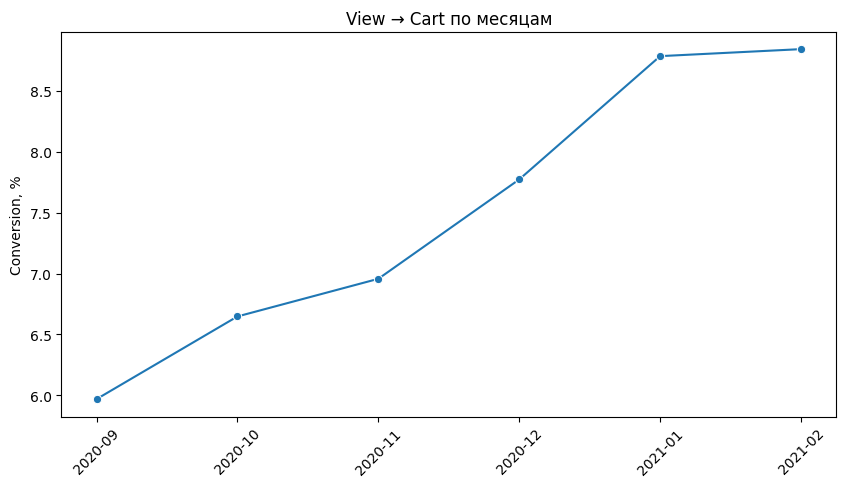

In [53]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_transitions,
    x="month",
    y="view_to_cart",
    marker="o"
)
plt.title("View → Cart по месяцам")
plt.xlabel("")
plt.ylabel("Conversion, %")
plt.xticks(rotation=45)
plt.show()

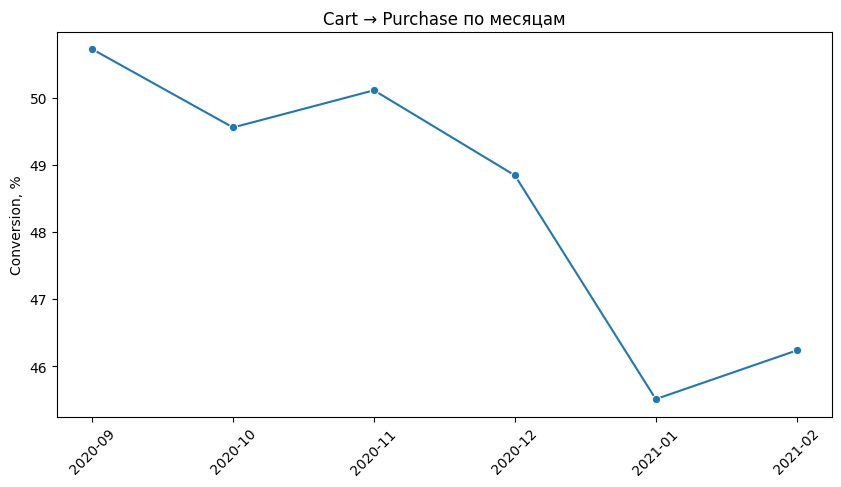

In [54]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_transitions,
    x="month",
    y="cart_to_purchase",
    marker="o"
)
plt.title("Cart → Purchase по месяцам")
plt.xlabel("")
plt.ylabel("Conversion, %")
plt.xticks(rotation=45)
plt.show()

In [55]:
category_volume = (
    product_session_events[
        product_session_events["has_view"]
        & (product_session_events["category"] != "unknown")
    ]
    .groupby("category")
    .size()
    .sort_values(ascending=False)
)

top_categories = category_volume.head(15).index

category_data = product_session_events[
    product_session_events["category"].isin(top_categories)
]

In [56]:
category_funnel = (
    category_data
    .groupby("category")
    .apply(
        lambda x: pd.Series({
            "views": x["has_view"].sum(),
            "view_to_cart": (
                (x["has_view"] & x["has_cart"]).sum()
                / x["has_view"].sum()
                * 100
            ),
            "cart_to_purchase": (
                (x["has_cart"] & x["has_purchase"]).sum()
                / x["has_cart"].sum()
                * 100
            ),
            "view_to_purchase": (
                (x["has_view"] & x["has_purchase"]).sum()
                / x["has_view"].sum()
                * 100
            )
        }),
        include_groups=False
    )
    .reset_index()
)

category_funnel.sort_values(
    "view_to_purchase",
    ascending=False
).round(2)

,category,views,view_to_cart,cart_to_purchase,view_to_purchase
5,computers.components.videocards,72107.0,16.35,40.23,6.98
14,stationery.cartrige,27111.0,10.29,60.52,6.53
7,computers.peripherals.printer,30003.0,9.72,54.54,5.65
6,computers.notebook,18007.0,7.81,58.95,4.94
3,computers.components.cpu,16533.0,12.56,35.74,4.70
12,electronics.telephone,61101.0,8.11,53.88,4.64
4,computers.components.motherboard,18538.0,10.65,39.97,4.50
11,electronics.tablet,14191.0,7.00,53.08,3.97
1,auto.accessories.player,13092.0,6.14,51.72,3.36
9,construction.tools.soldering,6627.0,5.61,50.27,3.08


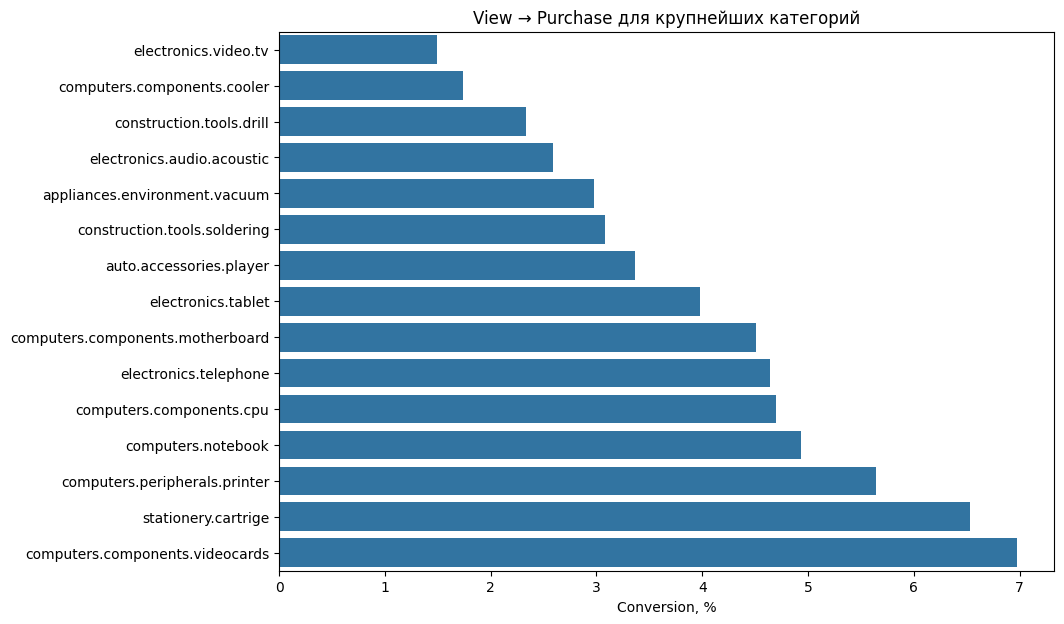

In [57]:
category_plot = category_funnel.sort_values(
    "view_to_purchase"
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=category_plot,
    x="view_to_purchase",
    y="category"
)
plt.title("View → Purchase для крупнейших категорий")
plt.xlabel("Conversion, %")
plt.ylabel("")
plt.show()

### Различия воронки между категориями

Воронка заметно различается между товарными категориями.

Видеокарты имеют высокий `View → Cart` — 16,35%, но `Cart → Purchase` составляет 40,23%.

Для ноутбуков `View → Cart` составляет 7,81%, а `Cart → Purchase` — 58,95%.

Особенно показательно сравнение процессоров и пылесосов: процессоры относительно часто добавляют в корзину, но слабее завершают покупку, тогда как у пылесосов добавление в корзину происходит реже, но после него конверсия в покупку выше.

Одинаковая итоговая конверсия может скрывать разные модели пользовательского поведения, поэтому место возникновения потерь следует анализировать отдельно по категориям.

## Драйвер роста выручки

In [58]:
monthly_category = (
    purchases.groupby(["month", "category_code"])
    .agg(
        purchases=("product_id", "size"),
        buyers=("user_id", "nunique"),
        revenue=("price", "sum"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

monthly_category["revenue_share"] = (
    monthly_category["revenue"]
    / monthly_category.groupby("month")["revenue"].transform("sum")
    * 100
)

In [59]:
november_categories = (
    monthly_category[
        (monthly_category["month"] == "2020-11")
        & (monthly_category["category_code"] != "unknown")
    ]
    .sort_values("revenue", ascending=False)
    .head(10)
)

november_categories.round(2)

,month,category_code,purchases,buyers,revenue,avg_price,revenue_share
165,2020-11,computers.components.videocards,589,337,207645.64,352.54,26.35
176,2020-11,computers.peripherals.printer,626,393,91894.53,146.80,11.66
158,2020-11,computers.components.cpu,315,179,59723.44,189.60,7.58
199,2020-11,electronics.telephone,913,564,30621.12,33.54,3.89
160,2020-11,computers.components.motherboard,291,163,24106.94,82.84,3.06
207,2020-11,stationery.cartrige,699,367,22908.27,32.77,2.91
153,2020-11,auto.accessories.player,168,86,21499.13,127.97,2.73
190,2020-11,electronics.audio.acoustic,202,107,20445.29,101.21,2.59
169,2020-11,computers.notebook,311,191,17984.64,57.83,2.28
198,2020-11,electronics.tablet,206,123,15168.97,73.64,1.93


In [60]:
january_categories = (
    monthly_category[
        (monthly_category["month"] == "2021-01")
        & (monthly_category["category_code"] != "unknown")
    ]
    .sort_values("revenue", ascending=False)
    .head(10)
)

january_categories.round(2)

,month,category_code,purchases,buyers,revenue,avg_price,revenue_share
323,2021-01,computers.components.videocards,2618,1609,1002194.45,382.81,67.33
334,2021-01,computers.peripherals.printer,485,261,65420.70,134.89,4.40
316,2021-01,computers.components.cpu,180,114,33641.83,186.90,2.26
354,2021-01,electronics.telephone,776,476,30216.01,38.94,2.03
361,2021-01,stationery.cartrige,458,250,20200.92,44.11,1.36
318,2021-01,computers.components.motherboard,253,138,19629.54,77.59,1.32
346,2021-01,electronics.audio.acoustic,175,88,18025.48,103.00,1.21
311,2021-01,auto.accessories.player,146,86,17656.62,120.94,1.19
327,2021-01,computers.notebook,255,166,14208.52,55.72,0.95
320,2021-01,computers.components.power_supply,125,82,14017.01,112.14,0.94


In [61]:
category_comparison = (
    monthly_category[
        monthly_category["month"].isin(["2020-11", "2021-01"])
        & (monthly_category["category_code"] != "unknown")
    ]
    .pivot_table(
        index="category_code",
        columns="month",
        values="revenue_share",
        fill_value=0
    )
    .reset_index()
)

category_comparison["change"] = (
    category_comparison["2021-01"]
    - category_comparison["2020-11"]
)

category_comparison.sort_values(
    "change",
    ascending=False
).head(15).round(2)

month,category_code,2020-11,2021-01,change
36,computers.components.videocards,26.35,67.33,40.98
33,computers.components.power_supply,0.80,0.94,0.14
19,auto.accessories.compressor,0.03,0.12,0.09
69,electronics.clocks,0.00,0.02,0.02
18,auto.accessories.alarm,0.06,0.08,0.01
34,computers.components.sound_card,0.00,0.01,0.01
25,auto.accessories.radar,0.01,0.02,0.01
0,accessories.bag,0.02,0.03,0.01
59,construction.tools.wrench,0.00,0.00,0.00
81,stationery.stapler,0.04,0.04,0.00


In [62]:
nov_revenue = monthly.loc[
    monthly["month"] == "2020-11", "revenue"
].iloc[0]

jan_revenue = monthly.loc[
    monthly["month"] == "2021-01", "revenue"
].iloc[0]

nov_videocards = november_categories.loc[
    november_categories["category_code"] == "computers.components.videocards",
    "revenue"
].iloc[0]

jan_videocards = january_categories.loc[
    january_categories["category_code"] == "computers.components.videocards",
    "revenue"
].iloc[0]

total_growth = jan_revenue - nov_revenue
videocard_growth = jan_videocards - nov_videocards

print("Рост общей выручки:", round(total_growth, 2))
print("Рост выручки видеокарт:", round(videocard_growth, 2))
print(
    "Доля видеокарт в росте:",
    round(videocard_growth / total_growth * 100, 2),
    "%"
)

Рост общей выручки: 700524.33
Рост выручки видеокарт: 794548.81
Доля видеокарт в росте: 113.42 %


In [63]:
videocards = monthly_category[
    monthly_category["category_code"]
    == "computers.components.videocards"
]

videocards[[
    "month",
    "purchases",
    "buyers",
    "revenue",
    "avg_price",
    "revenue_share"
]].round(2)

,month,purchases,buyers,revenue,avg_price,revenue_share
16,2020-09,47,24,15516.10,330.13,16.10
85,2020-10,294,165,94747.51,322.27,16.84
165,2020-11,589,337,207645.64,352.54,26.35
242,2020-12,877,546,331101.87,377.54,40.72
323,2021-01,2618,1609,1002194.45,382.81,67.33
397,2021-02,2463,1406,953559.23,387.15,69.26


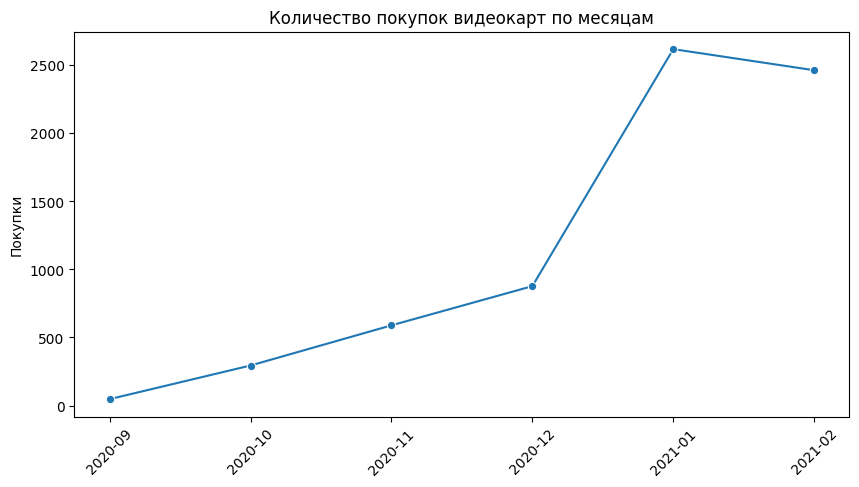

In [64]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=videocards,
    x="month",
    y="purchases",
    marker="o"
)
plt.title("Количество покупок видеокарт по месяцам")
plt.xlabel("")
plt.ylabel("Покупки")
plt.xticks(rotation=45)
plt.show()

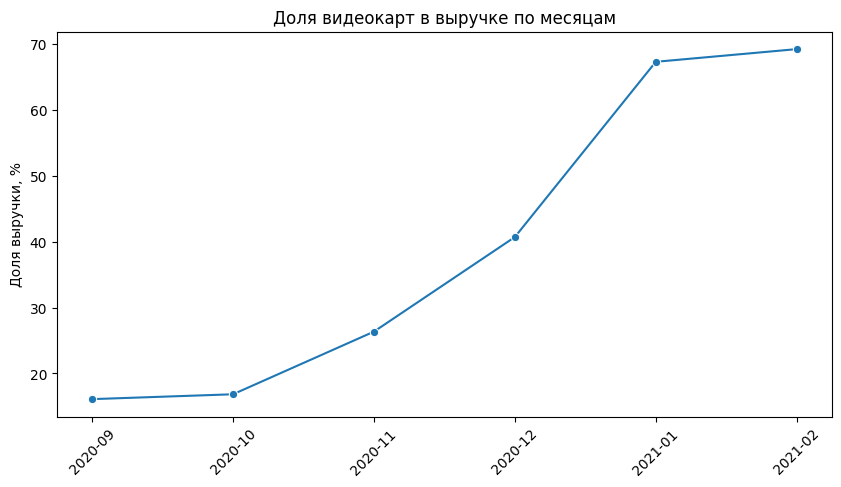

In [65]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=videocards,
    x="month",
    y="revenue_share",
    marker="o"
)
plt.title("Доля видеокарт в выручке по месяцам")
plt.xlabel("")
plt.ylabel("Доля выручки, %")
plt.xticks(rotation=45)
plt.show()

### Причина роста выручки

Рост выручки в январе был практически полностью связан с категорией `computers.components.videocards`.

С ноября по январь:

- число purchase-событий видеокарт выросло с 589 до 2618;
- количество покупателей — с 337 до 1609;
- выручка категории — с 207,6 тыс. до 1,00 млн;
- доля видеокарт в общей выручке — с 26,35% до 67,33%.

Общая выручка между ноябрём и январём выросла примерно на 700,5 тыс., тогда как выручка видеокарт увеличилась примерно на 794,5 тыс.

Рост видеокарт составляет **113,4% общего прироста**, то есть остальные категории в совокупности показали снижение.

Рост общей метрики скрывает существенное изменение структуры продаж и увеличение зависимости бизнеса от одной товарной категории.

## Цена и прохождение воронки

In [66]:
price_data = product_session_events[
    product_session_events["has_view"]
].copy()

price_data["price_segment"] = pd.qcut(
    price_data["price"],
    4,
    labels=["Low", "Medium", "High", "Very high"]
)

price_data.groupby(
    "price_segment",
    observed=True
)["price"].agg(
    min_price="min",
    max_price="max",
    median_price="median"
).round(2)

,min_price,max_price,median_price
price_segment,,,
Low,0.22,25.29,15.21
Medium,25.30,63.92,40.95
High,63.94,176.17,99.84
Very high,176.21,64771.06,327.43


In [67]:
price_funnel = (
    price_data
    .groupby("price_segment", observed=True)
    .apply(
        lambda x: pd.Series({
            "views": len(x),
            "view_to_cart": (
                (x["has_view"] & x["has_cart"]).sum()
                / x["has_view"].sum()
                * 100
            ),
            "cart_to_purchase": (
                (x["has_cart"] & x["has_purchase"]).sum()
                / x["has_cart"].sum()
                * 100
            ),
            "view_to_purchase": (
                (x["has_view"] & x["has_purchase"]).sum()
                / x["has_view"].sum()
                * 100
            )
        }),
        include_groups=False
    )
    .reset_index()
)

price_funnel.round(2)

,price_segment,views,view_to_cart,cart_to_purchase,view_to_purchase
0,Low,161448.0,6.34,55.37,3.73
1,Medium,161051.0,7.10,52.78,3.98
2,High,161121.0,6.98,45.73,3.41
3,Very high,161023.0,10.53,41.55,4.63


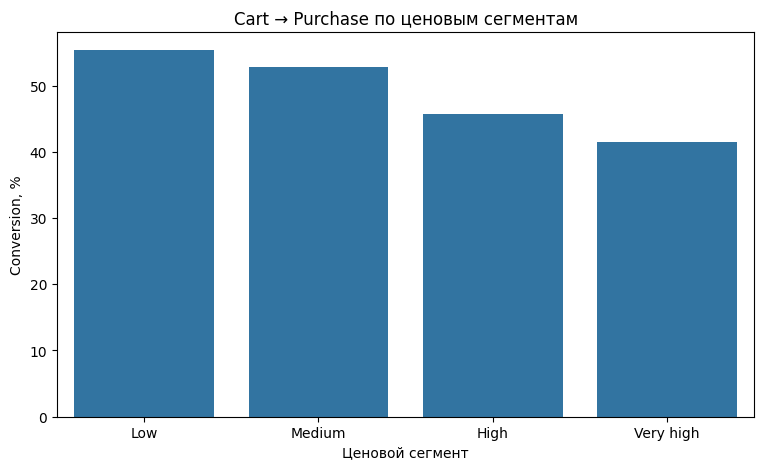

In [68]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=price_funnel,
    x="price_segment",
    y="cart_to_purchase"
)
plt.title("Cart → Purchase по ценовым сегментам")
plt.xlabel("Ценовой сегмент")
plt.ylabel("Conversion, %")
plt.show()

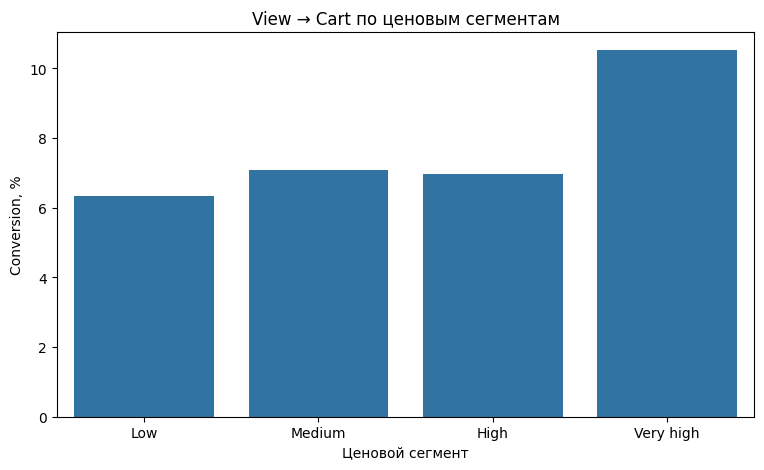

In [69]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=price_funnel,
    x="price_segment",
    y="view_to_cart"
)
plt.title("View → Cart по ценовым сегментам")
plt.xlabel("Ценовой сегмент")
plt.ylabel("Conversion, %")
plt.show()

In [70]:
selected_categories = [
    "computers.components.videocards",
    "electronics.telephone",
    "computers.notebook",
    "computers.peripherals.printer"
]

category_price = product_session_events[
    product_session_events["has_view"]
    & product_session_events["category"].isin(selected_categories)
].copy()

category_price["price_group"] = (
    category_price.groupby("category")["price"]
    .transform(lambda x: x > x.median())
    .map({
        False: "Below median",
        True: "Above median"
    })
)

In [71]:
category_price_funnel = (
    category_price
    .groupby(["category", "price_group"])
    .apply(
        lambda x: pd.Series({
            "views": len(x),
            "view_to_cart": (
                (x["has_view"] & x["has_cart"]).sum()
                / x["has_view"].sum()
                * 100
            ),
            "cart_to_purchase": (
                (x["has_cart"] & x["has_purchase"]).sum()
                / x["has_cart"].sum()
                * 100
            ),
            "view_to_purchase": (
                (x["has_view"] & x["has_purchase"]).sum()
                / x["has_view"].sum()
                * 100
            )
        }),
        include_groups=False
    )
    .reset_index()
)

category_price_funnel.round(2)

,category,price_group,views,view_to_cart,cart_to_purchase,view_to_purchase
0,computers.components.videocards,Above median,29158.0,16.29,42.02,7.24
1,computers.components.videocards,Below median,42949.0,16.40,39.12,6.80
2,computers.notebook,Above median,8949.0,7.63,55.05,4.50
3,computers.notebook,Below median,9058.0,7.98,62.24,5.37
4,computers.peripherals.printer,Above median,14725.0,10.27,52.58,5.72
5,computers.peripherals.printer,Below median,15278.0,9.20,56.58,5.57
6,electronics.telephone,Above median,29126.0,6.12,47.28,3.07
7,electronics.telephone,Below median,31975.0,9.93,57.54,6.08


### Цена и прохождение воронки

На уровне всего магазина `Cart → Purchase` последовательно снижается от 55,37% для наиболее дешёвого сегмента до 41,55% для наиболее дорогого.

Однако эта зависимость не является универсальной внутри отдельных категорий.

Для телефонов, ноутбуков и принтеров товары выше медианной стоимости имеют более низкую `Cart → Purchase`. Для видеокарт наблюдается обратная картина: более дорогие товары имеют немного более высокую конверсию.

Следовательно, агрегированную связь между ценой и конверсией нельзя интерпретировать как прямое влияние цены: существенную роль играет структура товарных категорий.

## Проверка статистических гипотез

Статистические тесты используются для проверки конкретных закономерностей, найденных в ходе EDA.

### Гипотеза 1. Стоимость телефона и завершение покупки

**H₀:** конверсия `Cart → Purchase` одинакова для телефонов ниже и выше медианной стоимости категории.

**H₁:** конверсия `Cart → Purchase` различается.

Для сравнения двух долей используется z-тест пропорций.

In [72]:
from statsmodels.stats.proportion import proportions_ztest

In [73]:
phone = category_price[
    (category_price["category"] == "electronics.telephone")
    & category_price["has_cart"]
].copy()

phone_stats = phone.groupby("price_group").agg(
    carts=("has_cart", "sum"),
    purchases=("has_purchase", "sum")
)

phone_stats["conversion"] = (
    phone_stats["purchases"] / phone_stats["carts"] * 100
)

phone_stats

,carts,purchases,conversion
price_group,,,
Above median,1783,843,47.279865
Below median,3175,1827,57.543307


In [74]:
groups = ["Below median", "Above median"]

count = phone_stats.loc[groups, "purchases"].values
nobs = phone_stats.loc[groups, "carts"].values

z_stat, p_value = proportions_ztest(count, nobs)

difference = (
    phone_stats.loc["Below median", "conversion"]
    - phone_stats.loc["Above median", "conversion"]
)

print("Разница:", round(difference, 2), "п.п.")
print("z-statistic:", round(z_stat, 2))
print("p-value:", p_value)

Разница: 10.26 п.п.
z-statistic: 6.96
p-value: 3.480625263102768e-12


### Результат гипотезы 1

Для телефонов ниже медианной стоимости `Cart → Purchase` составляет **57,54%**, а для телефонов выше медианы — **47,28%**.

Разница составляет **10,26 п.п.**, `p-value = 3,48 × 10⁻¹²`.

Нулевая гипотеза отвергается: наблюдаемое различие статистически значимо.

При этом результат показывает связь стоимости с поведением пользователей внутри данной категории, но не доказывает причинного влияния цены на решение о покупке.

### Первые и повторные сессии

В агрегированных данных повторные сессии имеют более высокую конверсию, чем первые. Однако такое сравнение может быть смещено составом групп, поэтому дополнительно проводится парное сравнение первой и второй сессии одних и тех же вернувшихся пользователей.

In [75]:
session_stats = session_stats.sort_values(
    ["user_id", "start_time"]
).reset_index(drop=True)

session_stats["session_number"] = (
    session_stats.groupby("user_id").cumcount() + 1
)

session_stats["session_type"] = np.where(
    session_stats["session_number"] == 1,
    "First",
    "Returning"
)

session_type_stats = session_stats.groupby("session_type").agg(
    sessions=("analysis_session_id", "size"),
    users=("user_id", "nunique"),
    purchase_sessions=("has_purchase", "sum"),
    avg_events=("events", "mean"),
    avg_products=("products", "mean")
)

session_type_stats["conversion"] = (
    session_type_stats["purchase_sessions"]
    / session_type_stats["sessions"]
    * 100
)

session_type_stats.round(2)

,sessions,users,purchase_sessions,avg_events,avg_products,conversion
session_type,,,,,,
First,407237,407237,17035,1.68,1.25,4.18
Returning,97393,45797,7471,2.05,1.43,7.67


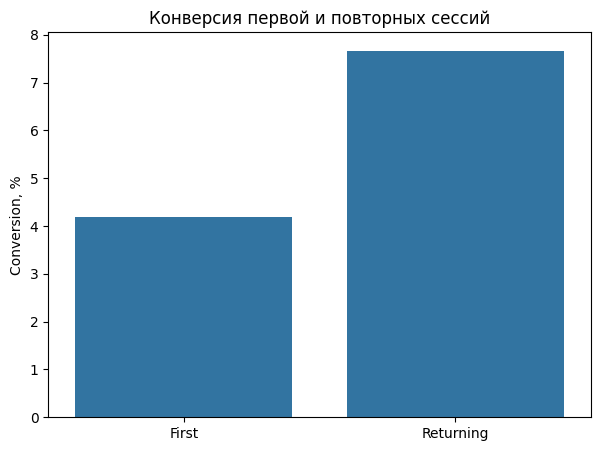

In [76]:
session_type_plot = session_type_stats.reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    data=session_type_plot,
    x="session_type",
    y="conversion"
)
plt.title("Конверсия первой и повторных сессий")
plt.xlabel("")
plt.ylabel("Conversion, %")
plt.show()

### Гипотеза 2. Первая и вторая сессии пользователя

Для статистической проверки рассматриваются только пользователи, имеющие как минимум две сессии.

**H₀:** вероятность покупки в первой и второй сессии одинакова.

**H₁:** вероятность покупки различается.

Поскольку сравниваются бинарные результаты для одних и тех же пользователей, используется тест Мак-Немара.

In [77]:
paired_sessions = (
    session_stats[
        session_stats["session_number"].isin([1, 2])
    ]
    .pivot(
        index="user_id",
        columns="session_number",
        values="has_purchase"
    )
    .dropna()
)

first_conversion = paired_sessions[1].mean() * 100
second_conversion = paired_sessions[2].mean() * 100

print("Первая сессия:", round(first_conversion, 2), "%")
print("Вторая сессия:", round(second_conversion, 2), "%")
print(
    "Разница:",
    round(second_conversion - first_conversion, 2),
    "п.п."
)

Первая сессия: 9.75 %
Вторая сессия: 8.54 %
Разница: -1.21 п.п.


In [78]:
transition_table = pd.crosstab(
    paired_sessions[1],
    paired_sessions[2]
).reindex(
    index=[False, True],
    columns=[False, True],
    fill_value=0
)

transition_table

2,False,True
1,,
False,38657,2675
True,3227,1238


In [79]:
from statsmodels.stats.contingency_tables import mcnemar

result = mcnemar(
    transition_table,
    exact=False,
    correction=True
)

print("statistic:", round(result.statistic, 2))
print("p-value:", result.pvalue)

statistic: 51.44
p-value: 7.380553570663692e-13


### Результат гипотезы 2

В агрегированных данных конверсия повторных сессий составляет **7,67%** против **4,18%** для первых.

Однако среди пользователей, которые действительно имеют минимум две сессии, конверсия первой сессии составляет **9,75%**, а второй — **8,54%**. Разница равна **−1,21 п.п.**

Тест Мак-Немара показал статистически значимое различие (`p < 0.001`).

Направление эффекта оказалось противоположным первоначальному агрегированному сравнению. Пользователи, которые в дальнейшем возвращаются, уже при первом посещении являются более вовлечённой аудиторией.

Следовательно, более высокая конверсия повторных сессий в агрегированных данных не доказывает, что сам повторный визит повышает вероятность покупки. Здесь проявляется эффект отбора пользователей.

## Retention и когортный анализ

Пользователи объединяются в когорты по месяцу их первого наблюдаемого посещения.

На первом этапе рассматривается **Activity Retention**: пользователь считается вернувшимся, если в соответствующем месяце зафиксировано хотя бы одно его действие.

Сентябрьская когорта требует осторожной интерпретации, поскольку данные начинаются только 24 сентября.

In [80]:
cohort_sessions = session_stats[
    ["user_id", "start_time"]
].copy()

cohort_sessions["activity_month"] = (
    cohort_sessions["start_time"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

first_month = (
    cohort_sessions
    .groupby("user_id")["activity_month"]
    .min()
    .rename("cohort_month")
)

cohort_sessions = cohort_sessions.merge(
    first_month,
    on="user_id"
)

cohort_sessions["cohort_index"] = (
    (
        cohort_sessions["activity_month"].dt.year
        - cohort_sessions["cohort_month"].dt.year
    ) * 12
    + cohort_sessions["activity_month"].dt.month
    - cohort_sessions["cohort_month"].dt.month
)

In [81]:
cohort_sizes = (
    cohort_sessions[
        cohort_sessions["cohort_index"] == 0
    ]
    .groupby("cohort_month")["user_id"]
    .nunique()
)

cohort_sizes

,user_id
cohort_month,
2020-09,15333
2020-10,83249
2020-11,90089
2020-12,69467
2021-01,78270
2021-02,70829


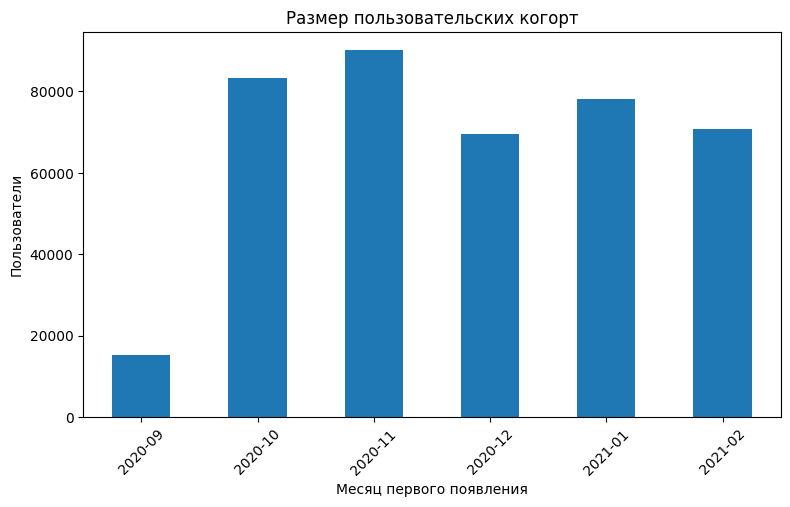

In [82]:
plt.figure(figsize=(9, 5))
cohort_sizes.plot(kind="bar")
plt.title("Размер пользовательских когорт")
plt.xlabel("Месяц первого появления")
plt.ylabel("Пользователи")
plt.xticks(rotation=45)
plt.show()

In [83]:
cohort_data = (
    cohort_sessions
    .groupby(["cohort_month", "cohort_index"])["user_id"]
    .nunique()
    .reset_index(name="users")
)

retention_users = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="users"
)

retention = (
    retention_users
    .div(retention_users[0], axis=0)
    * 100
)

retention.columns = [
    f"M{i}" for i in retention.columns
]

retention.index = retention.index.astype(str)

retention.round(2)

,M0,M1,M2,M3,M4,M5
cohort_month,,,,,,
2020-09,100.0,6.22,1.74,0.78,0.64,0.47
2020-10,100.0,2.68,0.81,0.53,0.34,NaN
2020-11,100.0,2.07,0.88,0.61,NaN,NaN
2020-12,100.0,2.37,1.02,NaN,NaN,NaN
2021-01,100.0,2.76,NaN,NaN,NaN,NaN
2021-02,100.0,NaN,NaN,NaN,NaN,NaN


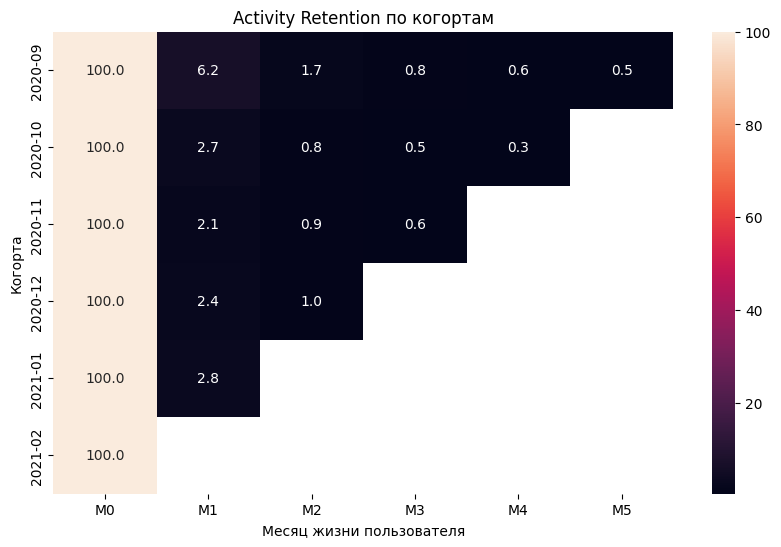

In [84]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f"
)

plt.title("Activity Retention по когортам")
plt.xlabel("Месяц жизни пользователя")
plt.ylabel("Когорта")
plt.show()

### Результаты Activity Retention

Для полноценных когорт октября–января M1 Activity Retention составляет от **2,07% до 2,76%**.

На горизонте M2 retention снижается примерно до **1%**, а затем остаётся ещё ниже.

Между полноценными когортами не наблюдается устойчивого тренда на улучшение или ухудшение M1 retention: показатель остаётся примерно на одном низком уровне.

Сентябрьская когорта показывает более высокий M1 — 6,22%, однако она сформирована только за часть месяца и напрямую не сопоставима с остальными.

Таким образом, слабая долгосрочная возвращаемость является одной из заметных особенностей пользовательского поведения.

## Purchase Retention

Activity Retention показывает повторное взаимодействие с магазином, но не показывает, продолжает ли пользователь покупать.

Для Purchase Retention пользователь относится к когорте по месяцу своей первой наблюдаемой покупки.

In [85]:
purchase_data = df[
    df["event_type"] == "purchase"
][["user_id", "event_time"]].copy()

purchase_data["purchase_month"] = (
    purchase_data["event_time"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

first_purchase = (
    purchase_data
    .groupby("user_id")["purchase_month"]
    .min()
    .rename("purchase_cohort")
)

purchase_data = purchase_data.merge(
    first_purchase,
    on="user_id"
)

purchase_data["cohort_index"] = (
    (
        purchase_data["purchase_month"].dt.year
        - purchase_data["purchase_cohort"].dt.year
    ) * 12
    + purchase_data["purchase_month"].dt.month
    - purchase_data["purchase_cohort"].dt.month
)

In [86]:
purchase_cohort_sizes = (
    purchase_data[
        purchase_data["cohort_index"] == 0
    ]
    .groupby("purchase_cohort")["user_id"]
    .nunique()
)

purchase_cohort_sizes

,user_id
purchase_cohort,
2020-09,627
2020-10,3772
2020-11,4258
2020-12,3782
2021-01,4673
2021-02,4192


In [87]:
purchase_cohort_data = (
    purchase_data
    .groupby(["purchase_cohort", "cohort_index"])["user_id"]
    .nunique()
    .reset_index(name="buyers")
)

purchase_retention_users = (
    purchase_cohort_data
    .pivot(
        index="purchase_cohort",
        columns="cohort_index",
        values="buyers"
    )
)

purchase_retention = (
    purchase_retention_users
    .div(purchase_retention_users[0], axis=0)
    * 100
)

purchase_retention.columns = [
    f"M{i}" for i in purchase_retention.columns
]

purchase_retention.index = (
    purchase_retention.index.astype(str)
)

purchase_retention.round(2)

,M0,M1,M2,M3,M4
purchase_cohort,,,,,
2020-09,100.0,3.83,0.80,0.32,0.16
2020-10,100.0,1.72,0.45,0.08,0.11
2020-11,100.0,1.60,0.61,0.16,NaN
2020-12,100.0,1.80,0.56,NaN,NaN
2021-01,100.0,2.50,NaN,NaN,NaN
2021-02,100.0,NaN,NaN,NaN,NaN


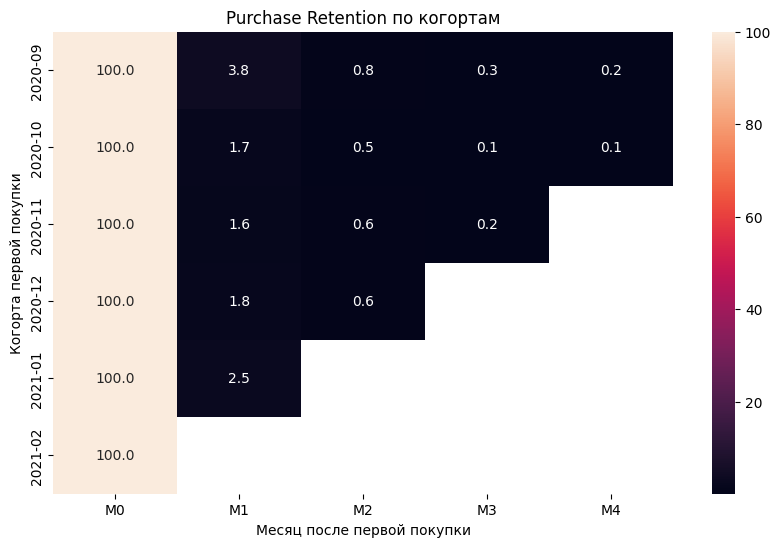

In [88]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    purchase_retention,
    annot=True,
    fmt=".1f"
)

plt.title("Purchase Retention по когортам")
plt.xlabel("Месяц после первой покупки")
plt.ylabel("Когорта первой покупки")
plt.show()

### Результаты Purchase Retention

Для полноценных когорт октября–января доля покупателей, совершивших новую покупку в следующем календарном месяце, составляет от **1,60% до 2,50%**.

На горизонте M2 повторную покупку совершает уже около **0,5–0,6%** исходной когорты.

Большинство покупателей не совершает новую покупку в последующие месяцы наблюдаемого периода.

При этом месячный Purchase Retention не учитывает повторные покупки внутри того же календарного месяца, поэтому далее анализируется повторное поведение на уровне покупательских сессий.

## Повторные покупательские сессии

В датасете отсутствует `order_id`, поэтому невозможно точно определить количество отдельных заказов.

Покупательской сессией считается аналитическая сессия, содержащая хотя бы одно событие `purchase`.

Повторным покупателем в этом разделе считается пользователь, имеющий покупки как минимум в двух разных аналитических сессиях.

In [89]:
purchase_sessions = (
    df[df["event_type"] == "purchase"]
    .groupby(["user_id", "analysis_session_id"])
    .agg(
        purchase_time=("event_time", "min"),
        revenue=("price", "sum")
    )
    .reset_index()
)

print("Покупателей:", purchase_sessions["user_id"].nunique())
print("Покупательских сессий:", len(purchase_sessions))

Покупателей: 21304
Покупательских сессий: 24506


In [90]:
buyer_stats = (
    purchase_sessions
    .groupby("user_id")
    .agg(
        purchase_sessions=("analysis_session_id", "nunique"),
        revenue=("revenue", "sum"),
        first_purchase=("purchase_time", "min"),
        last_purchase=("purchase_time", "max")
    )
    .reset_index()
)

buyer_stats["purchase_sessions"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

,purchase_sessions
count,21304.000000
mean,1.150300
std,0.487882
min,1.000000
50%,1.000000
75%,1.000000
90%,2.000000
95%,2.000000
99%,3.000000
max,10.000000


In [91]:
repeat_purchase_rate = (
    buyer_stats["purchase_sessions"].ge(2).mean() * 100
)

print(
    "Repeat Purchase Session Rate:",
    round(repeat_purchase_rate, 2),
    "%"
)

Repeat Purchase Session Rate: 11.53 %


In [92]:
buyer_stats["purchase_group"] = pd.cut(
    buyer_stats["purchase_sessions"],
    bins=[0, 1, 2, 3, float("inf")],
    labels=["1", "2", "3", "4+"]
)

purchase_distribution = (
    buyer_stats["purchase_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

purchase_distribution.columns = [
    "purchase_sessions",
    "buyers"
]

purchase_distribution["share"] = (
    purchase_distribution["buyers"]
    / purchase_distribution["buyers"].sum()
    * 100
)

purchase_distribution

,purchase_sessions,buyers,share
0,1,18847,88.466955
1,2,1941,9.110965
2,3,390,1.830642
3,4+,126,0.591438


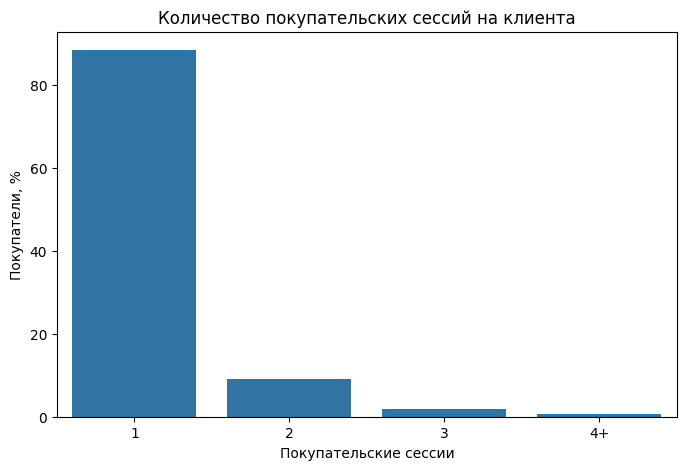

In [93]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=purchase_distribution,
    x="purchase_sessions",
    y="share"
)

plt.title("Количество покупательских сессий на клиента")
plt.xlabel("Покупательские сессии")
plt.ylabel("Покупатели, %")
plt.show()

In [94]:
purchase_sessions = purchase_sessions.sort_values(
    ["user_id", "purchase_time"]
)

purchase_sessions["purchase_number"] = (
    purchase_sessions.groupby("user_id").cumcount() + 1
)

first_second = (
    purchase_sessions[
        purchase_sessions["purchase_number"].isin([1, 2])
    ]
    .pivot(
        index="user_id",
        columns="purchase_number",
        values="purchase_time"
    )
    .dropna()
)

first_second["days_to_second_purchase"] = (
    first_second[2] - first_second[1]
).dt.total_seconds() / 86400

first_second["days_to_second_purchase"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

,days_to_second_purchase
count,2457.000000
mean,4.756591
std,11.174638
min,0.021076
25%,0.092998
50%,0.762199
75%,3.955845
90%,13.815563
95%,23.960296
99%,54.589849


In [95]:
time_groups = pd.cut(
    first_second["days_to_second_purchase"],
    bins=[0, 1, 7, 14, 30, 60, float("inf")],
    labels=[
        "< 1 дня",
        "1–7 дней",
        "8–14 дней",
        "15–30 дней",
        "31–60 дней",
        "60+ дней"
    ],
    include_lowest=True
)

time_distribution = (
    time_groups
    .value_counts()
    .sort_index()
    .reset_index()
)

time_distribution.columns = ["period", "buyers"]

time_distribution["share"] = (
    time_distribution["buyers"]
    / time_distribution["buyers"].sum()
    * 100
)

time_distribution

,period,buyers,share
0,< 1 дня,1391,56.613757
1,1–7 дней,669,27.228327
2,8–14 дней,160,6.512007
3,15–30 дней,146,5.942206
4,31–60 дней,71,2.889703
5,60+ дней,20,0.814001


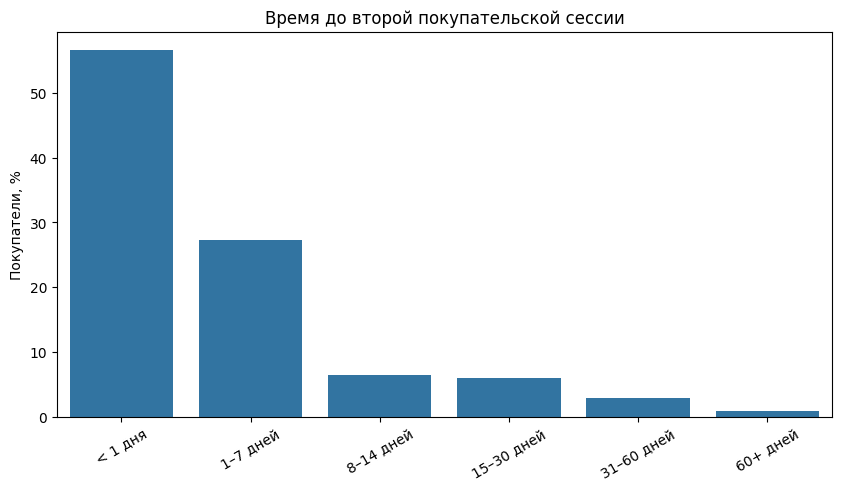

In [96]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=time_distribution,
    x="period",
    y="share"
)

plt.title("Время до второй покупательской сессии")
plt.xlabel("")
plt.ylabel("Покупатели, %")
plt.xticks(rotation=30)
plt.show()

In [97]:
purchase_sessions["purchase_date"] = (
    purchase_sessions["purchase_time"].dt.date
)

purchase_days = (
    purchase_sessions
    .groupby("user_id")["purchase_date"]
    .nunique()
)

repeat_day_rate = purchase_days.ge(2).mean() * 100

print(
    "Покупатели с покупками в разные дни:",
    round(repeat_day_rate, 2),
    "%"
)

Покупатели с покупками в разные дни: 7.63 %


### Результаты повторного покупательского поведения

Среди 21 304 покупателей **11,53%** имеют более одной покупательской сессии за период наблюдения. 88,47% покупателей представлены только одной покупательской сессией.

Медианное время между первой и второй покупательской сессией составляет около **0,76 дня**.

- 56,6% вторых покупательских сессий происходят менее чем через сутки;
- около 83,8% — в течение первой недели;
- около 90,4% — в течение двух недель.

Высокая концентрация повторных сессий в первые сутки может отражать как реальное повторное поведение, так и особенности аналитического определения сессии. Поэтому показатель интерпретируется как **Repeat Purchase Session Rate**, а не как точный Repeat Purchase Rate по заказам.

## Revenue Cohorts и Observed LTV

Для оценки денежной ценности покупателей используется когортный анализ выручки.

Пользователь относится к когорте по месяцу первой наблюдаемой покупки.

Из-за ограниченного периода наблюдения рассчитывается **Observed LTV** — накопленная выручка на одного исходного покупателя за доступный период.

In [98]:
revenue_data = df[
    df["event_type"] == "purchase"
][["user_id", "event_time", "price"]].copy()

revenue_data["purchase_month"] = (
    revenue_data["event_time"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

first_purchase_month = (
    revenue_data
    .groupby("user_id")["purchase_month"]
    .min()
    .rename("cohort_month")
)

revenue_data = revenue_data.merge(
    first_purchase_month,
    on="user_id"
)

revenue_data["cohort_index"] = (
    (
        revenue_data["purchase_month"].dt.year
        - revenue_data["cohort_month"].dt.year
    ) * 12
    + revenue_data["purchase_month"].dt.month
    - revenue_data["cohort_month"].dt.month
)

In [99]:
cohort_revenue = (
    revenue_data
    .groupby(["cohort_month", "cohort_index"])["price"]
    .sum()
    .reset_index(name="revenue")
)

cohort_revenue.head(10)

,cohort_month,cohort_index,revenue
0,2020-09,0,96353.01
1,2020-09,1,7492.75
2,2020-09,2,1435.71
3,2020-09,3,191.05
4,2020-09,4,240.28
5,2020-10,0,555097.64
6,2020-10,1,17421.87
7,2020-10,2,6204.19
8,2020-10,3,686.51
9,2020-10,4,1158.14


In [100]:
cohort_revenue["revenue_per_buyer"] = (
    cohort_revenue["revenue"]
    / cohort_revenue["cohort_month"]
        .map(purchase_cohort_sizes)
)

revenue_matrix = cohort_revenue.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="revenue_per_buyer"
)

revenue_matrix.round(2)

cohort_index,0,1,2,3,4
cohort_month,,,,,
2020-09,153.67,11.95,2.29,0.30,0.38
2020-10,147.16,4.62,1.64,0.18,0.31
2020-11,180.61,2.99,2.23,0.22,NaN
2020-12,209.93,6.51,1.09,NaN,NaN
2021-01,311.02,12.12,NaN,NaN,NaN
2021-02,313.45,NaN,NaN,NaN,NaN


In [101]:
observed_ltv = revenue_matrix.cumsum(axis=1)

observed_ltv.columns = [
    f"M{i}" for i in observed_ltv.columns
]

observed_ltv.index = observed_ltv.index.astype(str)

observed_ltv.round(2)

,M0,M1,M2,M3,M4
cohort_month,,,,,
2020-09,153.67,165.62,167.91,168.22,168.60
2020-10,147.16,151.78,153.43,153.61,153.92
2020-11,180.61,183.59,185.82,186.04,NaN
2020-12,209.93,216.44,217.52,NaN,NaN
2021-01,311.02,323.14,NaN,NaN,NaN
2021-02,313.45,NaN,NaN,NaN,NaN


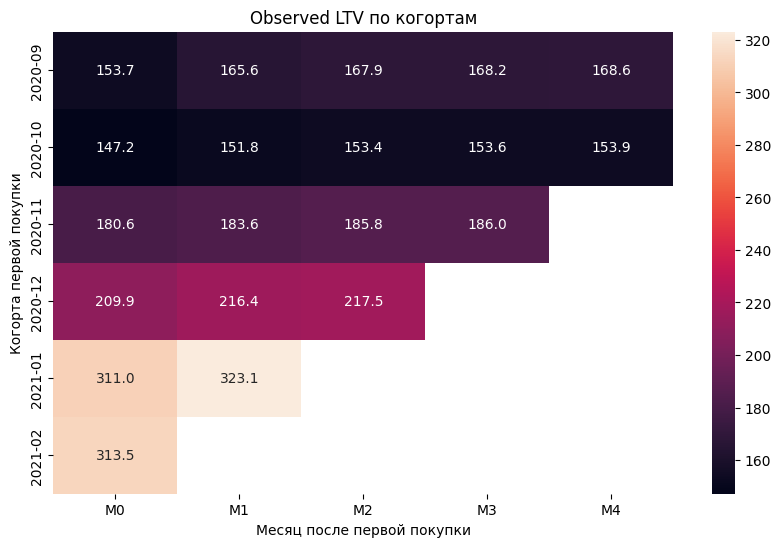

In [102]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    observed_ltv,
    annot=True,
    fmt=".1f"
)

plt.title("Observed LTV по когортам")
plt.xlabel("Месяц после первой покупки")
plt.ylabel("Когорта первой покупки")
plt.show()

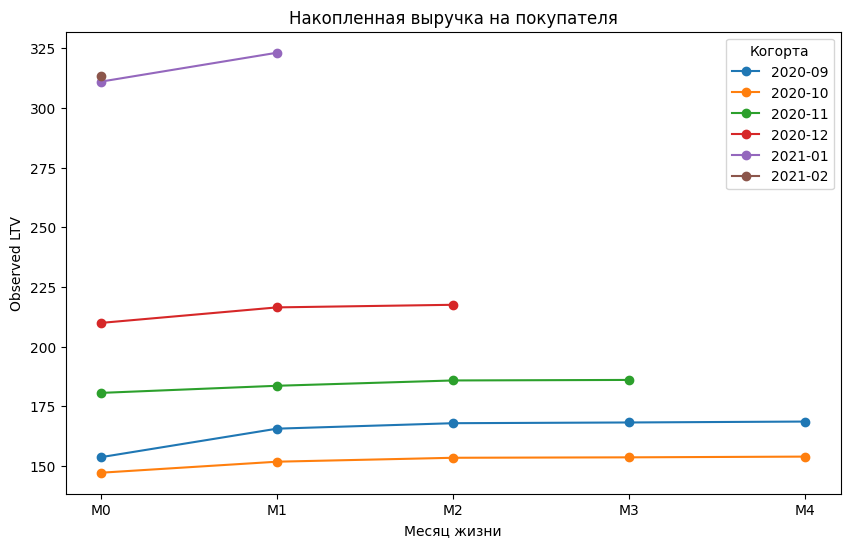

In [103]:
ltv_plot = observed_ltv.T

plt.figure(figsize=(10, 6))

for cohort in ltv_plot.columns:
    plt.plot(
        ltv_plot.index,
        ltv_plot[cohort],
        marker="o",
        label=cohort
    )

plt.title("Накопленная выручка на покупателя")
plt.xlabel("Месяц жизни")
plt.ylabel("Observed LTV")
plt.legend(title="Когорта")
plt.show()

In [104]:
ltv_summary = pd.DataFrame({
    "M0": observed_ltv["M0"],
    "last_observed": observed_ltv.apply(
        lambda row: row.dropna().iloc[-1],
        axis=1
    )
})

ltv_summary["growth_after_M0"] = (
    (ltv_summary["last_observed"] / ltv_summary["M0"] - 1) * 100
)

ltv_summary["M0_share"] = (
    ltv_summary["M0"] / ltv_summary["last_observed"] * 100
)

ltv_summary.round(2)

,M0,last_observed,growth_after_M0,M0_share
cohort_month,,,,
2020-09,153.67,168.60,9.71,91.15
2020-10,147.16,153.92,4.59,95.61
2020-11,180.61,186.04,3.01,97.08
2020-12,209.93,217.52,3.62,96.51
2021-01,311.02,323.14,3.90,96.25
2021-02,313.45,313.45,0.00,100.00


### Результаты Observed LTV

Наблюдаемая ценность покупателей заметно различается между когортами.

M0 увеличивается от 147,16 для октябрьской когорты до 311,02 для январской и 313,45 для февральской.

При этом рост LTV внутри одной когорты после месяца первой покупки невелик. Для полноценных когорт октября–января последующие месяцы увеличивают накопленную выручку на покупателя примерно на **3–5%**.

Около **96–97% Observed LTV** формируется уже в M0.

Более высокий Observed LTV поздних когорт нельзя автоматически интерпретировать как улучшение качества клиентской базы: ранее было показано значительное увеличение доли дорогой категории видеокарт в структуре продаж.

## Ключевые показатели

In [105]:
total_users = df["user_id"].nunique()
total_sessions = df["analysis_session_id"].nunique()
buyers = df.loc[df["event_type"] == "purchase", "user_id"].nunique()
revenue = df.loc[df["event_type"] == "purchase", "price"].sum()

user_conversion = buyers / total_users * 100
session_conversion = session_stats["has_purchase"].mean() * 100
arpu = revenue / total_users
arppu = revenue / buyers

kpi = pd.DataFrame({
    "Метрика": [
        "Пользователи",
        "Сессии",
        "Покупатели",
        "Выручка",
        "User Conversion",
        "Session Conversion",
        "ARPU",
        "ARPPU",
        "Repeat Purchase Session Rate"
    ],
    "Значение": [
        total_users,
        total_sessions,
        buyers,
        revenue,
        user_conversion,
        session_conversion,
        arpu,
        arppu,
        repeat_purchase_rate
    ]
})

kpi["Значение"] = kpi["Значение"].round(2)

kpi

,Метрика,Значение
0,Пользователи,407237.00
1,Сессии,504630.00
2,Покупатели,21304.00
3,Выручка,5125113.92
4,User Conversion,5.23
5,Session Conversion,4.86
6,ARPU,12.59
7,ARPPU,240.57
8,Repeat Purchase Session Rate,11.53


## Итоговый dashboard

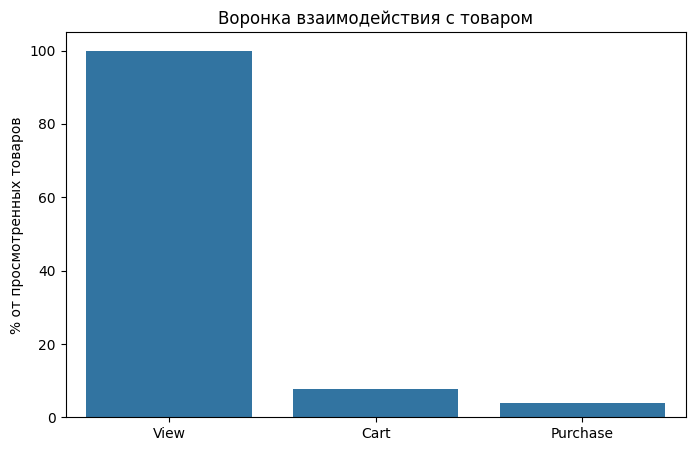

In [106]:
funnel_plot = pd.DataFrame({
    "stage": ["View", "Cart", "Purchase"],
    "conversion": [100, 7.73, 3.94]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=funnel_plot,
    x="stage",
    y="conversion"
)

plt.title("Воронка взаимодействия с товаром")
plt.xlabel("")
plt.ylabel("% от просмотренных товаров")
plt.show()

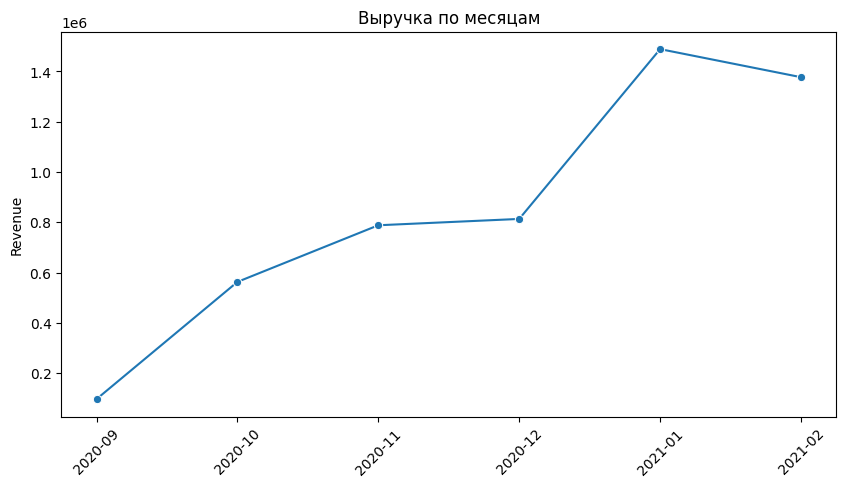

In [107]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly,
    x="month",
    y="revenue",
    marker="o"
)

plt.title("Выручка по месяцам")
plt.xlabel("")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

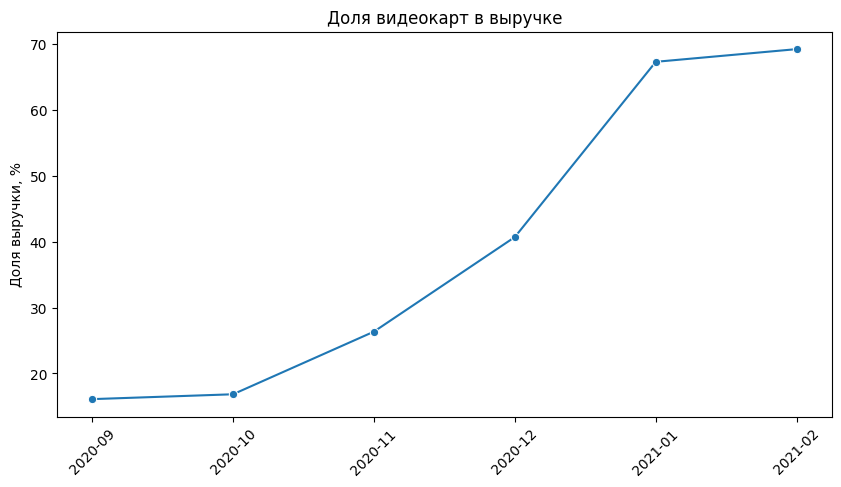

In [108]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=videocards,
    x="month",
    y="revenue_share",
    marker="o"
)

plt.title("Доля видеокарт в выручке")
plt.xlabel("")
plt.ylabel("Доля выручки, %")
plt.xticks(rotation=45)
plt.show()

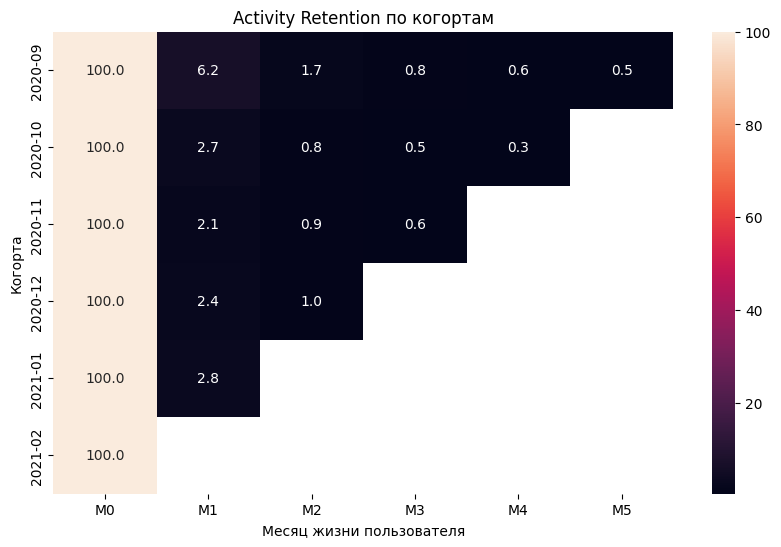

In [109]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f"
)

plt.title("Activity Retention по когортам")
plt.xlabel("Месяц жизни пользователя")
plt.ylabel("Когорта")
plt.show()

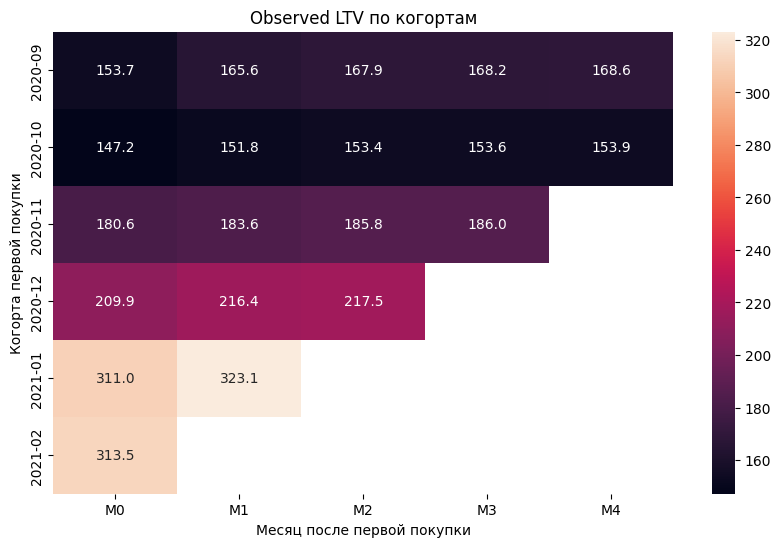

In [110]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    observed_ltv,
    annot=True,
    fmt=".1f"
)

plt.title("Observed LTV по когортам")
plt.xlabel("Месяц после первой покупки")
plt.ylabel("Когорта первой покупки")
plt.show()

# Итоговые выводы

### 1. Основная потеря пользователей происходит до добавления товара в корзину

На уровне одного товара внутри одной сессии конверсия `View → Cart` составляет **7,73%**, тогда как `Cart → Purchase` — **47,92%**.

Наиболее значительный drop-off наблюдается между просмотром товара и формированием выраженного намерения совершить покупку.

При этом воронка существенно различается между категориями, поэтому общая конверсия магазина скрывает разные модели пользовательского поведения.

### 2. Рост выручки произошёл без роста аудитории

С ноября 2020 года по январь 2021 года количество активных пользователей снизилось примерно на **12%**, однако месячная выручка выросла почти на **89%**.

За этот же период User Conversion увеличилась с **4,67% до 5,87%**, а средняя стоимость purchase-события выросла примерно со **104 до 179**.

Рост выручки происходил не благодаря увеличению трафика, а благодаря более эффективной монетизации существующей аудитории и изменению структуры покупок.

### 3. Главным драйвером роста стали видеокарты

Доля категории `computers.components.videocards` в общей выручке выросла с **26,35% в ноябре до 67,33% в январе** и 69,26% в феврале.

Между ноябрём и январём общая выручка магазина выросла примерно на 700,5 тыс., тогда как выручка видеокарт увеличилась примерно на 794,5 тыс.

Таким образом, рост видеокарт составляет **113,4% общего прироста**: остальные категории в совокупности показали снижение выручки.

### 4. Цена связана с прохождением воронки, но эффект зависит от категории

На уровне всего магазина `Cart → Purchase` снижается с **55,37%** для наиболее дешёвого сегмента до **41,55%** для наиболее дорогого.

Однако после анализа внутри отдельных категорий выяснилось, что такая зависимость не универсальна.

Для телефонов конверсия товаров ниже медианной стоимости составляет **57,54%**, а выше медианы — **47,28%**. Разница 10,26 п.п. статистически значима (`p < 0.001`).

Для видеокарт аналогичного снижения не наблюдается.

### 5. Возвращающиеся пользователи отличаются от аудитории в целом, но повторный визит сам по себе не объясняет рост конверсии

В агрегированных данных повторные сессии имеют более высокую конверсию: **7,67% против 4,18%**.

Однако при парном сравнении первой и второй сессии одних и тех же вернувшихся пользователей конверсия снижается с **9,75% до 8,54%**.

Тест Мак-Немара подтверждает статистически значимое различие (`p < 0.001`).

Это показывает эффект отбора: пользователи, которые в дальнейшем возвращаются, уже во время первого посещения являются более вовлечённой аудиторией.

### 6. Долгосрочная возвращаемость пользователей низкая

Для полноценных когорт октября–января M1 Activity Retention находится примерно на уровне **2–3%**.

M1 Purchase Retention составляет примерно **1,6–2,5%**.

Устойчивого улучшения retention между полноценными когортами не наблюдается.

### 7. Повторное покупательское поведение ограничено

**88,47%** покупателей имеют только одну покупательскую сессию.

Repeat Purchase Session Rate составляет **11,53%**.

Более половины вторых покупательских сессий происходят менее чем через сутки после первой, а около 84% — в течение первой недели.

### 8. Основная наблюдаемая ценность покупателя создаётся при первой покупке

Для полноценных когорт около **96–97% Observed LTV** формируется уже в M0.

Последующие месяцы увеличивают накопленную выручку на покупателя только примерно на **3–5%**.

Более высокий Observed LTV поздних когорт во многом совпадает с ростом доли дорогой категории видеокарт и не может автоматически интерпретироваться как улучшение качества клиентской базы.

# Бизнес-рекомендации

### 1. Исследовать причины низкого `View → Cart`

Основная потеря происходит до добавления товара в корзину. Для категорий с высоким трафиком и низкой конверсией стоит отдельно исследовать карточку товара, наличие, условия доставки, цену и качество информации о продукте.

### 2. Использовать разные стратегии для разных категорий

Категории с низким `View → Cart` требуют работы с этапом выбора товара. Категории с высоким добавлением в корзину и низким `Cart → Purchase` требуют анализа причин отказа уже после формирования намерения купить.

### 3. Отдельно анализировать дорогие товары

Для ряда категорий, особенно телефонов, более высокая цена связана с меньшей вероятностью завершения покупки после добавления товара в корзину. Потенциальные изменения необходимо проверять экспериментально.

### 4. Не оценивать состояние бизнеса только по общей выручке

Рост общей выручки оказался практически полностью обусловлен одной категорией. Вместе с revenue необходимо отслеживать структуру выручки по категориям и концентрацию бизнеса.

### 5. Исследовать механики повторного взаимодействия после первой покупки

Retention и рост Observed LTV после M0 находятся на низком уровне. Это делает механики повторного взаимодействия отдельным направлением для продуктовых экспериментов.

### 6. Проверять рекомендации через A/B-тесты

Наблюдательные данные позволяют находить закономерности, но не доказывают причинность. Изменения карточек товаров, коммуникаций, скидок и сценариев корзины следует проверять контролируемыми экспериментами.

## Возможные продуктовые эксперименты

### Эксперимент 1. Улучшение карточки товара

Для категорий с большим количеством просмотров и низким `View → Cart` можно протестировать изменение карточки товара.

Основная метрика:

\[
ViewToCartCR = \frac{Cart}{View}
\]

Дополнительная метрика — `View → Purchase`.

### Эксперимент 2. Работа с дорогими товарами в корзине

Для дорогих телефонов можно протестировать механизм снижения барьера покупки, например дополнительный способ оплаты или рассрочку.

Основная метрика:

\[
CartToPurchaseCR = \frac{Purchase}{Cart}
\]

Дополнительные метрики — revenue per buyer и другие guardrail-метрики при наличии соответствующих данных.

### Эксперимент 3. Повторная коммуникация после покупки

Можно протестировать персональную рекомендацию или CRM-коммуникацию после первой покупки.

Основная метрика — Repeat Purchase Rate на фиксированном временном горизонте.

Дополнительные метрики — revenue per buyer и retention.

# Ограничения исследования

- Датасет охватывает период с 24 сентября 2020 года по 28 февраля 2021 года, поэтому полный жизненный цикл пользователей неизвестен.
- История пользователей до начала периода наблюдений отсутствует. Первое наблюдаемое посещение или покупка не обязательно являются реальными первыми взаимодействиями пользователя с магазином.
- Сентябрь является неполным месяцем и не используется как полноценная когорта при сравнении retention.
- Исходный `user_session` оказался ненадёжным для определения отдельных посещений. В проекте используется аналитическое определение сессии: новая сессия начинается после перерыва более 30 минут.
- В данных отсутствует `order_id`, поэтому невозможно точно определить число отдельных заказов. Для анализа повторного поведения используются покупательские сессии.
- Отсутствует количество единиц товара в заказе, поэтому revenue рассчитывается как сумма `price` по событиям `purchase`.
- В данных отсутствуют себестоимость, маржинальность и стоимость привлечения пользователей. Observed LTV отражает выручку, а не прибыль клиента.
- Около четверти исходных событий не имеют информации о категории или бренде.
- Наблюдаемые зависимости не доказывают причинно-следственную связь. Для проверки продуктовых изменений необходимы контролируемые эксперименты.